# Analisis Sentimen Program Makan Bergizi Gratis di Twitter
## dengan Naive Bayes: Perbandingan Dampak Kualitas Labeling dari Dua LLM (GPT dan Claude)

**Nama:** Cevin Jonathan Liep  
**NIM:** 0706022210035  
**Program Studi:** S1 Sistem Informasi  
**Universitas Ciputra Surabaya**  

---
### Struktur Notebook
1. Install & Import Libraries
2. Konfigurasi & Keywords
3. Modul Pengumpulan Data (Advanced Search + Reply Scraping)
4. Modul Preprocessing
5. Modul Labeling Multi-LLM (GPT & Claude via OpenRouter)
6. Feature Extraction (TF-IDF)
7. Model Training (Naive Bayes A & B)
8. Evaluasi & Perbandingan Model
9. Statistical Testing (Paired T-Test + 5-Fold CV)
10. Visualisasi (Word Cloud, Distribusi Sentimen, Top Keywords)
---

## Cell 1 — Install & Import Libraries

In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================

# --- Install (jalankan sekali saja) ---
# !pip install pandas scikit-learn nltk matplotlib seaborn wordcloud requests tqdm scipy

# --- Standard Libraries ---
import os
import re
import json
import time
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# --- Data Manipulation ---
import pandas as pd
import numpy as np

# --- HTTP Requests ---
import requests
from tqdm import tqdm

# --- NLP & Preprocessing ---
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# --- Machine Learning ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline

# --- Statistical Testing ---
from scipy import stats

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

print("✅ Semua library berhasil diimport!")
print(f"   pandas     : {pd.__version__}")
print(f"   scikit-learn: sudah tersedia")
print(f"   nltk       : {nltk.__version__}")

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


✅ Semua library berhasil diimport!
   pandas     : 3.0.2
   scikit-learn: sudah tersedia
   nltk       : 3.9.3


## Cell 2 — Konfigurasi Global & Keyword Setup

In [ ]:
# ============================================================
# CELL 2: Konfigurasi Global & Keyword Setup
# ============================================================

# --- API Keys (baca dari environment variable untuk keamanan) ---
import os
TWITTER_API_KEY   = os.getenv("TWITTER_API_KEY", "")
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")

# Validasi API key - warning aja, tidak error (mock mode akan jalan)
if not OPENROUTER_API_KEY.startswith("sk-or-v1-"):
    print("⚠️ OPENROUTER_API_KEY tidak valid. Running in MOCK MODE (random labels)")

print(f"✅ API Keys dimuat dari environment variables")

# --- Tanggal Pengumpulan Data ---
START_DATE = "2024-02-01"
END_DATE   = "2025-12-31"

# --- Target Volume Data ---
TARGET_CLEAN_MIN  = 1500
TARGET_CLEAN_MAX  = 2000
RAW_SCRAPE_TARGET = 3000   # raw sebelum filtering (hard cap)

# --- Model LLM (OpenRouter model strings) ---
GPT_MODEL    = "openai/gpt-4o-mini"          # cost-effective GPT via OpenRouter
CLAUDE_MODEL = "anthropic/claude-haiku-4-5"  # Claude Haiku via OpenRouter

# --- Seed Keywords (Manual Base) ---
seed_keywords = [
    "Program Makan Bergizi Gratis",
    "Makan Gratis",
    "MBG",
    "Nutrisi Gratis"
]

# --- LLM-Generated Keywords ---
llm_keywords_output = [
    {"keyword": "Program Makan Bergizi Gratis",                  "kategori": "exact phrase"},
    {"keyword": "Makan Bergizi Gratis",                          "kategori": "exact phrase"},
    {"keyword": "MBG",                                           "kategori": "acronym"},
    {"keyword": "program MBG Prabowo",                           "kategori": "context"},
    {"keyword": "kebijakan makan gratis kabinet baru",            "kategori": "context"},
    {"keyword": "MBG untuk atasi stunting",                      "kategori": "policy term"},
    {"keyword": "anggaran subsidi nutrisi sekolah",               "kategori": "policy term"},
    {"keyword": "efektivitas Program Makan Bergizi Gratis",       "kategori": "sentiment"},
    {"keyword": "dukung Makan Bergizi Gratis demi generasi emas", "kategori": "sentiment"},
    {"keyword": "kritik kebijakan MBG",                          "kategori": "sentiment"},
    {"keyword": "MBG solusi stunting atau gimmick",               "kategori": "sentiment"},
    {"keyword": "school feeding program ala Indonesia",           "kategori": "context"},
    {"keyword": "free nutritious meal program",                   "kategori": "context"},
    {"keyword": "impact MBG ke APBN",                            "kategori": "policy term"},
    {"keyword": "transparansi anggaran makan gratis",             "kategori": "sentiment"},
    {"keyword": "Prabowo dan janji makan siang gratis",           "kategori": "context"},
    {"keyword": "kabinet bahas implementasi MBG",                 "kategori": "context"},
    {"keyword": "pro kontra Makan Bergizi Gratis",                "kategori": "sentiment"},
]

# --- Final Keyword Set (setelah validasi manual) ---
# Keyword dioptimalkan untuk Advanced Search query (short & high-recall)
FINAL_KEYWORDS = [
    "makan bergizi gratis",
    "MBG prabowo",
    "program makan gratis",
    "makan gratis prabowo",
    "nutrisi gratis sekolah",
    "program bergizi stunting",
    "kebijakan MBG",
    "implementasi MBG",
]

# --- Output Paths (TA FINAL) ---
BASE_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RAW_DATA_PATH        = f"{OUTPUT_DIR}/raw_tweets.csv"
CLEAN_DATA_PATH      = f"{OUTPUT_DIR}/clean_tweets.csv"
LABELED_GPT_PATH     = f"{OUTPUT_DIR}/labeled_gpt.csv"
LABELED_CLAUDE_PATH  = f"{OUTPUT_DIR}/labeled_claude.csv"
RESULTS_PATH         = f"{OUTPUT_DIR}/evaluation_results.json"

print("✅ Konfigurasi berhasil dimuat!")
print(f"   Periode data    : {START_DATE} s/d {END_DATE}")
print(f"   Target tweets   : {TARGET_CLEAN_MIN}–{TARGET_CLEAN_MAX} (clean)")
print(f"   Final keywords  : {len(FINAL_KEYWORDS)} keywords")
print(f"   GPT model       : {GPT_MODEL}")
print(f"   Claude model    : {CLAUDE_MODEL}")
print(f"   Output dir      : {OUTPUT_DIR}/")

✅ API Keys dimuat dari environment variables
✅ Konfigurasi berhasil dimuat!
   Periode data    : 2024-02-01 s/d 2025-12-31
   Target tweets   : 1500–2000 (clean)
   Final keywords  : 8 keywords
   GPT model       : openai/gpt-4o-mini
   Claude model    : anthropic/claude-haiku-4-5
   Output dir      : ./output/


## Cell 3 — Modul Pengumpulan Data
**Alur:**  
1. `search_viral_tweets()` — Advanced Search per keyword → ambil tweet dengan engagement tinggi (viral)  
2. `scrape_replies()` — Get Tweet Replies per tweet induk viral  
3. Gabungkan tweets + replies → deduplicate → simpan raw CSV

In [ ]:
# CELL 3: Twitter Data Collection + Preprocessing

# ============================================================
# PREPROCESSING FUNCTIONS (dipindahkan dari Cell 4)
# ============================================================

# --- Stopwords ---
indonesian_stopwords = set(stopwords.words("indonesian"))
custom_stopwords = {
    "yg","dgn","utk","krn","klo","kalo","tapi","udah","aja","deh","dong","sih","loh","lah",
    "nya","nih","kan","juga","jg","ga","gak","nggak","gimana","gitu","gini","tuh","itu","ini",
    "sdh","blm","lg","lagi","udh","gue","gw","lo","lu","http","https","www","co","rt","amp","via"
}
negation_words = {"tidak", "bukan", "belum", "jangan", "tanpa", "tak"}
all_stopwords = (indonesian_stopwords | custom_stopwords) - negation_words

def step1_cleaning(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@[\w]+", " ", text)
    text = re.sub(r"#[\w]+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def step2_case_folding(text: str) -> str:
    return text.lower()

def step3_tokenizing(text: str) -> list:
    return word_tokenize(text)

def step4_stopword_removal(tokens: list) -> list:
    return [t for t in tokens if t not in all_stopwords and len(t) >= 2]

def full_preprocess(text: str) -> str:
    return " ".join(
        step4_stopword_removal(
            step3_tokenizing(
                step2_case_folding(
                    step1_cleaning(text)
                )
            )
        )
    )

print("✅ Preprocessing functions loaded!")

# ============================================================
# CELL 3A: Helper Functions — twitterapi.io Client + BONUS
# ============================================================

BASE_URL = "https://api.twitterapi.io"
HEADERS  = {"X-API-Key": TWITTER_API_KEY}

# Optimasi dari 10 keyword inti (base) + keyword turunan
BASE_KEYWORDS_10 = [
    "makan bergizi gratis",
    "MBG",
    "program makan gratis",
    "makan gratis prabowo",
    "nutrisi gratis sekolah",
    "program bergizi",
    "MBG stunting",
    "makan siang gratis",
    "anggaran MBG",
    "free school meal indonesia",
]

KEYWORD_VARIANTS = {
    "makan bergizi gratis": ["program makan bergizi gratis", "makan bergizi prabowo"],
    "MBG": ["MBG prabowo", "kebijakan MBG", "implementasi MBG", "MBG sekolah"],
    "program makan gratis": ["makan gratis anak sekolah", "makan gratis SD SMP"],
    "nutrisi gratis sekolah": ["program gizi anak", "gizi gratis murid"],
    "program bergizi": ["subsidi makan bergizi", "program bergizi prabowo"],
    "MBG stunting": ["program stunting makan"],
    "makan siang gratis": ["makan siang gratis sekolah"],
    "anggaran MBG": ["anggaran makan gratis", "MBG anggaran", "MBG korupsi"],
}

def build_optimized_keywords(base_keywords, variants_map, max_keywords=24):
    pool = []
    seen = set()

    def _add(k):
        kk = str(k).strip()
        norm = kk.lower()
        if kk and norm not in seen:
            pool.append(kk)
            seen.add(norm)

    for b in base_keywords:
        _add(b)
    for b in base_keywords:
        for v in variants_map.get(b, []):
            _add(v)

    return pool[:max_keywords]

def hashtag_variants(text: str) -> list:
    raw = str(text).strip()
    raw = re.sub(r"[^A-Za-z0-9\s]", " ", raw)
    raw = re.sub(r"\s+", " ", raw).strip()
    parts_raw = [p for p in raw.split(" ") if len(p) >= 2]
    if not parts_raw:
        return []

    parts_low = [p.lower() for p in parts_raw]
    camel = "#" + parts_low[0] + "".join(p.capitalize() for p in parts_low[1:])
    pascal = "#" + "".join(p.capitalize() for p in parts_low)
    upper = "#" + "".join(p.upper() for p in parts_low)

    out = [camel, pascal, upper]
    return list(dict.fromkeys(out))

EXTENDED_KEYWORDS = build_optimized_keywords(BASE_KEYWORDS_10, KEYWORD_VARIANTS, max_keywords=12)

HASHTAG_KEYWORDS = []
for b in BASE_KEYWORDS_10:
    HASHTAG_KEYWORDS.extend(hashtag_variants(b))
for b in BASE_KEYWORDS_10:
    for v in KEYWORD_VARIANTS.get(b, []):
        HASHTAG_KEYWORDS.extend(hashtag_variants(v))
HASHTAG_KEYWORDS = list(dict.fromkeys(HASHTAG_KEYWORDS))[:24]

# Cost profile: hashtag-first (sesuai preferensi terbaru)
ENABLE_HASHTAGS = True
MAX_SEARCH_TERMS = 24
SEARCH_POOL = (HASHTAG_KEYWORDS + EXTENDED_KEYWORDS) if ENABLE_HASHTAGS else EXTENDED_KEYWORDS
SEARCH_TERMS = list(dict.fromkeys(SEARCH_POOL))[:MAX_SEARCH_TERMS]

def parse_tweet(tweet, source_type="search"):
    """Normalisasi satu objek tweet dari API response ke row DataFrame."""
    author = tweet.get("author", {})
    return {
        "tweet_id": tweet.get("id", ""),
        "tweet_url": tweet.get("url", ""),
        "text": tweet.get("text", ""),
        "created_at": tweet.get("createdAt", ""),
        "lang": tweet.get("lang", ""),
        "like_count": tweet.get("likeCount", 0),
        "retweet_count": tweet.get("retweetCount", 0),
        "reply_count": tweet.get("replyCount", 0),
        "quote_count": tweet.get("quoteCount", 0),
        "view_count": tweet.get("viewCount", 0),
        "is_reply": tweet.get("isReply", False),
        "in_reply_to_id": tweet.get("inReplyToId", ""),
        "conversation_id": tweet.get("conversationId", ""),
        "username": author.get("userName", ""),
        "followers": author.get("followers", 0),
        "tweet_length": len(tweet.get("text", "")),
        "contains_url": bool(tweet.get("entities", {}).get("urls")),
        "contains_media": bool(tweet.get("entities", {}).get("media")),
        "source_type": source_type,
    }

def search_tweets_paginated(keyword, max_results=200, start_date=START_DATE,
                            end_date=END_DATE, min_likes=0, query_type="Latest",
                            max_pages=6, timeout_sec=15):
    """Search tweets dengan pagination untuk keyword tertentu."""
    all_tweets = []
    cursor = None
    seen_cursors = set()
    page = 0
    term = str(keyword).strip()
    term_query = term if term.startswith("#") else f'"{term}"'

    if min_likes > 0:
        query = f'{term_query} lang:id since:{start_date} until:{end_date} min_faves:{min_likes} -filter:retweets'
    else:
        query = f'{term_query} lang:id since:{start_date} until:{end_date} -filter:retweets'

    while len(all_tweets) < max_results and page < max_pages:
        params = {"query": query, "queryType": query_type}
        if cursor:
            if cursor in seen_cursors:
                break
            seen_cursors.add(cursor)
            params["cursor"] = cursor

        try:
            resp = requests.get(
                f"{BASE_URL}/twitter/tweet/advanced_search",
                headers=HEADERS,
                params=params,
                timeout=timeout_sec,
            )
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f"   Error halaman {page+1} keyword '{keyword}': {e}")
            break

        tweets = data.get("tweets", [])
        if not tweets:
            break

        for t in tweets:
            all_tweets.append(parse_tweet(t, source_type="search"))

        page += 1
        if page == 1 or page % 2 == 0:
            print(f"      ↳ {keyword} page {page}/{max_pages} | collected: {len(all_tweets)}")
        cursor = data.get("next_cursor") or data.get("cursor")
        if not cursor:
            break
        time.sleep(0.6)

    return all_tweets[:max_results]

def scrape_replies_safe(tweet_id, max_replies=None, verbose=False):
    """Scrape replies dari satu tweet dengan error handling + parsing fleksibel response."""
    all_replies = []
    cursor = None

    while True:
        params = {"tweetId": tweet_id}
        if cursor:
            params["cursor"] = cursor

        try:
            resp = requests.get(
                f"{BASE_URL}/twitter/tweet/replies",
                headers=HEADERS,
                params=params,
                timeout=20,
            )
            if resp.status_code == 404:
                break
            resp.raise_for_status()
            data = resp.json()
            replies = data.get("replies") or data.get("tweets") or data.get("data", {}).get("replies") or []
            if isinstance(replies, dict):
                replies = replies.get("items", [])
            if not replies:
                break
            for r in replies:
                all_replies.append(parse_tweet(r, source_type="reply"))
                if max_replies is not None and len(all_replies) >= max_replies:
                    break
            cursor = data.get("next_cursor") or data.get("cursor")
            if not cursor:
                break
            if max_replies is not None and len(all_replies) >= max_replies:
                break
        except Exception as e:
            if verbose:
                print(f"   ⚠️ replies gagal untuk {tweet_id}: {str(e)[:120]}")
            break
        time.sleep(0.4)

    return all_replies

print("✅ Helper functions siap!")
print(f"   Keyword terms : {len(EXTENDED_KEYWORDS)}")
print(f"   Hashtag terms : {len(HASHTAG_KEYWORDS)}")
print(f"   Hashtags aktif: {ENABLE_HASHTAGS}")
print(f"   Total search terms: {len(SEARCH_TERMS)}")

# ============================================================
# CELL 3B: Scraping Fresh Data
# ============================================================

USE_EXISTING_RAW = True  # demo: pakai data lama jika tersedia

print("\n" + "=" * 60)
print("🔄 SCRAPING FRESH DATA FROM TWITTER")
print("=" * 60)

# ===================== TARGET & LIMIT =====================
# Fokus target utama: clean 1500–2000 (praktis stop di sekitar 1800 clean)
CLEAN_TARGET_STOP = 1800
EST_CLEAN_RATIO = 0.70
RAW_SOFT_TARGET = max(2200, int(CLEAN_TARGET_STOP / EST_CLEAN_RATIO))  # ~2570 unik raw
RAW_HARD_CAP = 3200

# Kontrol eksekusi fase
RUN_PHASE_1_2 = True
RUN_PHASE_3 = False  # ubah ke True saat ingin lanjut reply scraping
RESET_FROM_SCRATCH = False  # default False agar data lama tetap dipakai saat rerun
PHASE12_SNAPSHOT_PATH = f"{OUTPUT_DIR}/raw_tweets_phase12.csv"

MAX_ROUNDS = 6
SEARCH_MAX_PAGES_PER_TERM = 4
SEARCH_TIMEOUT_SEC = 12
REPLY_MAX_PER_THREAD = 20
REPLY_THREADS_PER_ROUND = 40
MIN_NEW_UNIQUE_PER_ROUND = 35
MIN_CLEAN_FOR_DUP_STREAK_STOP = 1500
DUP_STREAK_STOP_TERMS = 20
TERMS_PER_ROUND = 8  # tiap round hanya eksekusi subset term agar R1/R2 tidak identik

# ===================== RESUME + DEDUP AWAL =====================
all_raw_tweets = []
if (not RESET_FROM_SCRATCH) and os.path.exists(RAW_DATA_PATH):
    try:
        df_seed = pd.read_csv(RAW_DATA_PATH, encoding="utf-8-sig")
        if "tweet_id" in df_seed.columns:
            df_seed = df_seed[df_seed["tweet_id"].astype(str).str.strip().ne("")].copy()
            df_seed = df_seed.drop_duplicates(subset=["tweet_id"], keep="first")
            all_raw_tweets = df_seed.to_dict(orient="records")
    except Exception as e:
        print(f"⚠️ Gagal load seed raw data: {str(e)[:120]}")

seen_ids = set()
for t in all_raw_tweets:
    tid = str(t.get("tweet_id", "")).strip()
    if tid:
        seen_ids.add(tid)

if USE_EXISTING_RAW and len(seen_ids) > 0:
    print("\n⚡ MODE DEMO: raw data sudah ada, scraping API dilewati.")
    RUN_PHASE_1_2 = False
    RUN_PHASE_3 = False
    RAW_SOFT_TARGET = len(seen_ids)

def add_unique_tweets(items):
    added = 0
    for it in items:
        tid = str(it.get("tweet_id", "")).strip()
        if not tid or tid in seen_ids:
            continue
        seen_ids.add(tid)
        all_raw_tweets.append(it)
        added += 1
    return added

n_kw = max(1, len(SEARCH_TERMS))
PER_KEYWORD_LATEST = max(100, int((RAW_SOFT_TARGET * 0.45) / n_kw))
PER_KEYWORD_TOP    = max(70, int((RAW_SOFT_TARGET * 0.30) / n_kw))

print(f"\n🎯 Target clean stop            : {CLEAN_TARGET_STOP}")
print(f"📈 Estimasi raw soft target      : {RAW_SOFT_TARGET}")
print(f"🧱 Raw hard cap                 : {RAW_HARD_CAP}")
print(f"📦 Seed unik dari file lama: {len(seen_ids)}")
print(f"⚙️ Quota/keyword -> Latest: {PER_KEYWORD_LATEST}, Top: {PER_KEYWORD_TOP}")
print(f"🧭 Run Phase 3? {RUN_PHASE_3}")
print(f"🧼 Reset from scratch? {RESET_FROM_SCRATCH}")

# Bagi rentang tanggal supaya tiap round (R1, R2, dst) query ke periode berbeda
_round_edges = pd.date_range(start=START_DATE, end=END_DATE, periods=MAX_ROUNDS + 1)

after_fase1 = len(all_raw_tweets)
after_fase2 = len(all_raw_tweets)
reply_threshold = 5
replied = 0
total_replies_collected = 0
scraped_reply_threads = set()
phase12_saved = False
duplicate_streak_terms = 0
stop_due_to_dup_streak = False

for round_idx in range(1, MAX_ROUNDS + 1):
    if not RUN_PHASE_1_2:
        break
    if stop_due_to_dup_streak:
        break
    if len(seen_ids) >= RAW_SOFT_TARGET:
        break
    round_start_unique = len(seen_ids)
    round_start_date = _round_edges[round_idx - 1].date().isoformat()
    round_end_date = _round_edges[round_idx].date().isoformat()

    # Active terms per round (rotating window)
    start_idx = ((round_idx - 1) * TERMS_PER_ROUND) % n_kw
    active_terms = []
    for i in range(min(TERMS_PER_ROUND, n_kw)):
        active_terms.append(SEARCH_TERMS[(start_idx + i) % n_kw])

    print(f"\n================ ROUND {round_idx}/{MAX_ROUNDS} ================")
    print(f"📅 Window: {round_start_date} s/d {round_end_date}")
    print(f"🔎 Active terms round ini: {len(active_terms)}")

    print("FASA 1: Latest Search per keyword")
    for kw in tqdm(active_terms, desc=f"Latest R{round_idx}"):
        results = search_tweets_paginated(keyword=kw, max_results=PER_KEYWORD_LATEST,
                                          start_date=round_start_date, end_date=round_end_date,
                                          min_likes=0, query_type="Latest",
                                          max_pages=SEARCH_MAX_PAGES_PER_TERM,
                                          timeout_sec=SEARCH_TIMEOUT_SEC)
        added = add_unique_tweets(results)
        after_u = len(seen_ids)
        dup = len(results) - added
        duplicate_streak_terms = (duplicate_streak_terms + 1) if added == 0 else 0
        est_clean_now = int(after_u * EST_CLEAN_RATIO)
        print(f"   [Latest] {kw} | raw:{len(results)} | dedup:+{added} | dup:{dup} | total unik:{after_u}")
        if est_clean_now >= MIN_CLEAN_FOR_DUP_STREAK_STOP and duplicate_streak_terms >= DUP_STREAK_STOP_TERMS:
            print(f"   ⛔ Stop: est clean {est_clean_now} >= {MIN_CLEAN_FOR_DUP_STREAK_STOP} dan {duplicate_streak_terms} term beruntun duplikat")
            stop_due_to_dup_streak = True
            break
        if len(seen_ids) >= RAW_SOFT_TARGET:
            print(f"   🛑 Stop: raw unik sudah {len(seen_ids)} (>= soft target {RAW_SOFT_TARGET})")
            break
        time.sleep(0.4)
    after_fase1 = len(all_raw_tweets)
    print(f"   Unik setelah Fase 1: {after_fase1}")

    if stop_due_to_dup_streak:
        break

    if len(seen_ids) < RAW_SOFT_TARGET:
        print("FASA 2: Top/Viral Search per keyword")
        for kw in tqdm(active_terms, desc=f"Top R{round_idx}"):
            results = search_tweets_paginated(keyword=kw, max_results=PER_KEYWORD_TOP,
                                              start_date=round_start_date, end_date=round_end_date,
                                              min_likes=0, query_type="Top",
                                              max_pages=SEARCH_MAX_PAGES_PER_TERM,
                                              timeout_sec=SEARCH_TIMEOUT_SEC)
            added = add_unique_tweets(results)
            after_u = len(seen_ids)
            dup = len(results) - added
            duplicate_streak_terms = (duplicate_streak_terms + 1) if added == 0 else 0
            est_clean_now = int(after_u * EST_CLEAN_RATIO)
            print(f"   [Top]    {kw} | raw:{len(results)} | dedup:+{added} | dup:{dup} | total unik:{after_u}")
            if est_clean_now >= MIN_CLEAN_FOR_DUP_STREAK_STOP and duplicate_streak_terms >= DUP_STREAK_STOP_TERMS:
                print(f"   ⛔ Stop: est clean {est_clean_now} >= {MIN_CLEAN_FOR_DUP_STREAK_STOP} dan {duplicate_streak_terms} term beruntun duplikat")
                stop_due_to_dup_streak = True
                break
            if len(seen_ids) >= RAW_SOFT_TARGET:
                print(f"   🛑 Stop: raw unik sudah {len(seen_ids)} (>= soft target {RAW_SOFT_TARGET})")
                break
            time.sleep(0.4)
    after_fase2 = len(all_raw_tweets)
    print(f"   Unik setelah Fase 2: {after_fase2}")

    if RUN_PHASE_3 and len(seen_ids) < RAW_SOFT_TARGET:
        if not phase12_saved:
            df_phase12_pre = pd.DataFrame(all_raw_tweets)
            if len(df_phase12_pre) > 0:
                df_phase12_pre = df_phase12_pre[df_phase12_pre["tweet_id"].astype(str).str.strip() != ""]
                df_phase12_pre = df_phase12_pre.drop_duplicates(subset=["tweet_id"], keep="first")
                if len(df_phase12_pre) > RAW_HARD_CAP:
                    df_phase12_pre = df_phase12_pre.sort_values(["like_count", "reply_count"], ascending=False).head(RAW_HARD_CAP)
                df_phase12_pre.to_csv(PHASE12_SNAPSHOT_PATH, index=False, encoding="utf-8-sig")
                print(f"\n💾 Snapshot PRE-Phase3 tersimpan: {PHASE12_SNAPSHOT_PATH} | rows: {len(df_phase12_pre)}")
            phase12_saved = True
        print("FASA 3: Reply Scraping")
        df_temp = pd.DataFrame(all_raw_tweets).drop_duplicates(subset=["tweet_id"])
        viral_ids = df_temp[
            (df_temp["source_type"].eq("search")) &
            (df_temp["reply_count"] >= reply_threshold) &
            (df_temp["tweet_id"].astype(str).str.strip() != "")
        ]["tweet_id"].tolist()

        if len(viral_ids) < 120:
            fallback_ids = (
                df_temp[df_temp["tweet_id"].astype(str).str.strip() != ""]
                .sort_values(["reply_count", "like_count"], ascending=False)["tweet_id"]
                .head(500)
                .tolist()
            )
            viral_ids = list(dict.fromkeys(viral_ids + fallback_ids))

        viral_ids = [tid for tid in viral_ids if str(tid) not in scraped_reply_threads]
        viral_ids = viral_ids[:REPLY_THREADS_PER_ROUND]
        print(f"   Kandidat reply thread: {len(viral_ids)} (limit round: {REPLY_THREADS_PER_ROUND})")

        for tweet_id in tqdm(viral_ids, desc=f"Replies R{round_idx}"):
            scraped_reply_threads.add(str(tweet_id))
            replies = scrape_replies_safe(tweet_id, max_replies=REPLY_MAX_PER_THREAD, verbose=False)
            if replies:
                added = add_unique_tweets(replies)
                if added > 0:
                    replied += 1
                    total_replies_collected += added
            if len(seen_ids) >= RAW_SOFT_TARGET:
                print(f"   🛑 Stop: raw unik sudah {len(seen_ids)} (>= soft target {RAW_SOFT_TARGET})")
                break
            time.sleep(0.35)

    round_gain = len(seen_ids) - round_start_unique
    print(f"   ✅ Total unik sementara: {len(all_raw_tweets)} (gain round: +{round_gain})")
    if round_gain < MIN_NEW_UNIQUE_PER_ROUND and len(seen_ids) < RAW_SOFT_TARGET:
        print(f"   ⛔ Early stop: gain round hanya {round_gain} (< {MIN_NEW_UNIQUE_PER_ROUND})")
        break

# Simpan snapshot hasil Fase 1&2 jika belum sempat disimpan
if not phase12_saved:
    df_phase12 = pd.DataFrame(all_raw_tweets)
    if len(df_phase12) > 0:
        df_phase12 = df_phase12[df_phase12["tweet_id"].astype(str).str.strip() != ""]
        df_phase12 = df_phase12.drop_duplicates(subset=["tweet_id"], keep="first")
        if len(df_phase12) > RAW_HARD_CAP:
            df_phase12 = df_phase12.sort_values(["like_count", "reply_count"], ascending=False).head(RAW_HARD_CAP)
        df_phase12.to_csv(PHASE12_SNAPSHOT_PATH, index=False, encoding="utf-8-sig")
        print(f"\n💾 Snapshot Fase 1&2 tersimpan: {PHASE12_SNAPSHOT_PATH} | rows: {len(df_phase12)}")

print(f"\n🧵 Thread reply yang nambah data: {replied}")
print(f"💬 Total reply unik ditambahkan : {total_replies_collected}")

print("\nFASA 4: Konsolidasi & Simpan")
df_raw = pd.DataFrame(all_raw_tweets)
df_raw = df_raw[df_raw["tweet_id"].astype(str).str.strip() != ""]
before_dedup = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=["tweet_id"], keep="first")
after_dedup = len(df_raw)

df_raw["created_at_dt"] = pd.to_datetime(df_raw["created_at"], errors="coerce", utc=True)
df_raw = df_raw[
    (df_raw["created_at_dt"] >= pd.Timestamp(START_DATE, tz="UTC")) &
    (df_raw["created_at_dt"] <= pd.Timestamp(END_DATE + " 23:59:59", tz="UTC"))
]
df_raw = df_raw.drop(columns=["created_at_dt"]).reset_index(drop=True)

if len(df_raw) > RAW_HARD_CAP:
    df_raw = df_raw.sort_values(["like_count", "reply_count"], ascending=False).head(RAW_HARD_CAP).reset_index(drop=True)

df_raw.to_csv(RAW_DATA_PATH, index=False, encoding="utf-8-sig")
print(f"\n   Sebelum deduplicate : {before_dedup}")
print(f"   Setelah deduplicate : {after_dedup}")
print(f"   Final raw tweets    : {len(df_raw)}")
print(f"\n✅ Raw data tersimpan: {RAW_DATA_PATH}")

print("\n📊 Distribusi Source:")
print(df_raw["source_type"].value_counts().to_string())

est_low = int(len(df_raw) * 0.70)
est_high = int(len(df_raw) * 0.85)
print(f"\n📈 Estimasi clean tweets: {est_low}–{est_high}")
status = "✅" if est_low >= TARGET_CLEAN_MIN else "⚠️  Perlu tambah scraping"
print(f"   Target {TARGET_CLEAN_MIN}–{TARGET_CLEAN_MAX}: {status}")

# ============================================================
# CELL 3A.5 (MERGED): Bonus Scraping — opsional
# ============================================================
# Jika ingin tambah data tanpa buat cell terpisah, set True.
ENABLE_BONUS_SCRAPING = False

if ENABLE_BONUS_SCRAPING and os.path.exists(RAW_DATA_PATH):
    df_existing = pd.read_csv(RAW_DATA_PATH)
    existing_count = len(df_existing)
    existing_ids = set(df_existing["tweet_id"].astype(str).unique())

    print("\n" + "=" * 70)
    print("BONUS SCRAPING v2 (MERGED): Broader Keywords")
    print("=" * 70)
    print(f"Current raw tweets: {existing_count}")
    print(f"Target: 2,500 (need {max(0, 2500 - existing_count)} more tweets)")

    bonus_tweets = []
    bonus_target = max(0, 2500 - existing_count)

    bonus_keywords = [
        "makan siang gratis",
        "stunting anak",
        "nutrisi sekolah",
        "anak bergizi",
        "gizi buruk",
        "makan bergizi",
        "program kesehatan anak",
        "pemenuhan gizi",
        "makanan bergizi gratis",
        "kebijakan pendidikan gizi",
    ]

    print("\n[FASE BONUS] Scraping dengan broader keywords")
    for kw in tqdm(bonus_keywords, desc="Bonus keyword search"):
        try:
            results = search_tweets_paginated(keyword=kw, max_results=100,
                                              min_likes=0, query_type="Latest")
            unique_results = [
                r for r in results
                if str(r.get("tweet_id", "")) not in existing_ids
            ]
            bonus_tweets.extend(unique_results)
            existing_ids.update([str(r.get("tweet_id", "")) for r in unique_results])

            print(f"   [{kw}] Scraped {len(results)}, Added {len(unique_results)} unique")
            time.sleep(1)

            if len(bonus_tweets) >= bonus_target > 0:
                print("\n   ✅ Target bonus reached! Stopping early...")
                break

        except Exception as e:
            print(f"   ⚠️  Error scraping '{kw}': {str(e)[:100]}")
            time.sleep(2)
            continue

    df_bonus = pd.DataFrame(bonus_tweets)
    if len(df_bonus) > 0:
        df_combined = pd.concat([df_existing, df_bonus], ignore_index=True)
        df_combined.to_csv(RAW_DATA_PATH, index=False, encoding="utf-8-sig")
        df_raw = df_combined.copy()

        print(f"\n✅ Raw data updated!")
        print(f"   Sebelum: {existing_count} tweets")
        print(f"   Tambahan: {len(df_bonus)} tweets")
        print(f"   Sesudah: {len(df_combined)} tweets")
    else:
        print("\n⚠️  No new unique bonus tweets scraped")

# ============================================================
# CELL 3C: Preprocessing Raw Tweets
# ============================================================
print("\n" + "=" * 60)
print("PREPROCESSING RAW TWEETS")
print("=" * 60)

df_raw["text_clean"] = df_raw["text"].apply(full_preprocess)

# --- Bangun tabel konteks reply -> headline untuk labeling ---
tweet_lookup = (
    df_raw[["tweet_id", "text"]]
    .dropna(subset=["tweet_id"])
    .drop_duplicates(subset=["tweet_id"], keep="first")
    .set_index("tweet_id")["text"]
    .to_dict()
)

df_raw["root_tweet_id"] = np.where(
    df_raw["source_type"].eq("reply"),
    df_raw["in_reply_to_id"].astype(str).str.strip(),
    df_raw["tweet_id"].astype(str).str.strip(),
)
df_raw["root_text"] = df_raw["root_tweet_id"].map(tweet_lookup).fillna("")
df_raw.loc[df_raw["source_type"] != "reply", "root_text"] = df_raw["text"].astype(str)

df_raw["text_for_labeling"] = np.where(
    df_raw["source_type"].eq("reply") & df_raw["root_text"].astype(str).str.strip().ne(""),
    "[KONTEKS_HEADLINE] " + df_raw["root_text"].astype(str) + " [ISI_REPLY] " + df_raw["text"].astype(str),
    df_raw["text"].astype(str),
)
df_raw["text_for_labeling_clean"] = df_raw["text_for_labeling"].apply(full_preprocess)

df_clean = df_raw[["tweet_id", "text", "text_clean", "text_for_labeling", "text_for_labeling_clean",
                   "created_at", "username", "like_count", "retweet_count", "reply_count",
                   "source_type", "conversation_id", "in_reply_to_id", "root_tweet_id", "root_text"]].copy()
df_clean = df_clean[(df_clean["text_for_labeling_clean"].str.len() > 2)]

# Hard cap clean data sesuai konfigurasi
if len(df_clean) > TARGET_CLEAN_MAX:
    df_clean = df_clean.head(TARGET_CLEAN_MAX).copy()

# Tabel konteks untuk audit dan debugging labeling
df_context = df_clean[df_clean["source_type"] == "reply"][[
    "tweet_id", "root_tweet_id", "root_text", "text", "text_for_labeling"
]].copy()
CONTEXT_TABLE_PATH = f"{OUTPUT_DIR}/reply_context_table.csv"
df_context.to_csv(CONTEXT_TABLE_PATH, index=False, encoding="utf-8-sig")

print(f"\n✅ Preprocessing selesai!")
print(f"   Tweets setelah preprocessing: {len(df_clean)}")
print(f"   Reply-context rows           : {len(df_context)}")
print(f"   Context table                : {CONTEXT_TABLE_PATH}")
print(f"   Sample text_clean:")
print(f"   {df_clean['text_clean'].iloc[0]}")
if len(df_context) > 0:
    print("\n🧩 Contoh context labeling (3 baris):")
    print(df_context.head(3).to_string(index=False))

df_clean.to_csv(CLEAN_DATA_PATH, index=False, encoding="utf-8-sig")
print(f"\n✅ Clean data tersimpan: {CLEAN_DATA_PATH}")

✅ Preprocessing functions loaded!
✅ Helper functions siap!
   Keyword terms : 12
   Hashtag terms : 24
   Hashtags aktif: True
   Total search terms: 24

🔄 SCRAPING FRESH DATA FROM TWITTER

🎯 Target clean stop            : 1800
📈 Estimasi raw soft target      : 2571
🧱 Raw hard cap                 : 3200
📦 Seed unik dari file lama: 2012
⚙️ Quota/keyword -> Latest: 100, Top: 70
🧭 Run Phase 3? False
🧼 Reset from scratch? False

================ ROUND 1/6 ================
📅 Window: 2024-02-01 s/d 2024-05-27
🔎 Active terms round ini: 8
FASA 1: Latest Search per keyword


Latest R1:   0%|          | 0/8 [00:00<?, ?it/s]

      ↳ #makanBergiziGratis page 1/4 | collected: 6
      ↳ #makanBergiziGratis page 2/4 | collected: 12
      ↳ #makanBergiziGratis page 4/4 | collected: 24
   [Latest] #makanBergiziGratis | raw:24 | dedup:+0 | dup:24 | total unik:2012


Latest R1:  12%|█▎        | 1/8 [00:09<01:03,  9.01s/it]

      ↳ #MakanBergiziGratis page 1/4 | collected: 6
      ↳ #MakanBergiziGratis page 2/4 | collected: 12
      ↳ #MakanBergiziGratis page 4/4 | collected: 24
   [Latest] #MakanBergiziGratis | raw:24 | dedup:+0 | dup:24 | total unik:2012


...

Bonus keyword search:  50%|█████     | 5/10 [01:55<01:49, 21.98s/it]

      ↳ makan bergizi page 1/6 | collected: 16
      ↳ makan bergizi page 2/6 | collected: 32
      ↳ makan bergizi page 4/6 | collected: 64
      ↳ makan bergizi page 6/6 | collected: 96
   [makan bergizi] Scraped 96, Added 66 unique


Bonus keyword search:  50%|█████     | 5/10 [02:16<02:16, 27.34s/it]


   ✅ Target bonus reached! Stopping early...

✅ Raw data updated!
   Sebelum: 2012 tweets
   Tambahan: 540 tweets
   Sesudah: 2552 tweets

PREPROCESSING RAW TWEETS



✅ Preprocessing selesai!
   Tweets setelah preprocessing: 2000
   Reply-context rows           : 0
   Context table                : ./output/reply_context_table.csv
   Sample text_clean:
   mencetak generasi bangsa sehat unggul diperkuat peresmian operasional sppg polri argorejo sedayu bantul senin 29 desember 2025 role model program makan bergizi gratis 2045

✅ Clean data tersimpan: ./output/clean_tweets.csv


In [22]:
# ============================================================
# CELL 3B: Load Existing Data (Jika sudah di-scrape sebelumnya)
# ============================================================

print("\n" + "=" * 60)
print("📂 LOADING EXISTING CLEAN DATA")
print("=" * 60)

# Load clean tweets yang sudah diproses sebelumnya
if os.path.exists(CLEAN_DATA_PATH):
    df_clean = pd.read_csv(CLEAN_DATA_PATH, encoding="utf-8-sig")
    print(f"\n✅ Clean data loaded: {CLEAN_DATA_PATH}")
    print(f"   Total tweets: {len(df_clean)}")
    print(f"   Columns: {list(df_clean.columns)}")
    print(f"\n📊 Distribusi Source:")
    if "source_type" in df_clean.columns:
        print(df_clean["source_type"].value_counts().to_string())
else:
    print(f"❌ File not found: {CLEAN_DATA_PATH}")
    print(f"   Jalankan Cell 3A untuk scrape data baru")
    df_clean = pd.DataFrame()


📂 LOADING EXISTING CLEAN DATA

✅ Clean data loaded: ./output/clean_tweets.csv
   Total tweets: 2000
   Columns: ['tweet_id', 'text', 'text_clean', 'text_for_labeling', 'text_for_labeling_clean', 'created_at', 'username', 'like_count', 'retweet_count', 'reply_count', 'source_type', 'conversation_id', 'in_reply_to_id', 'root_tweet_id', 'root_text']

📊 Distribusi Source:
source_type
search    2000


## Cell 4 — Modul Preprocessing
Mengikuti BAB 2.2.4: Cleaning → Case Folding → Tokenizing → Stopword Removal

In [23]:
# ============================================================
# CELL 4: Modul Preprocessing (SELF-CONTAINED)
# ============================================================

# --- Stopwords ---
indonesian_stopwords = set(stopwords.words("indonesian"))
custom_stopwords = {
    "yg","dgn","utk","krn","klo","kalo","tapi","udah","aja","deh","dong","sih","loh","lah",
    "nya","nih","kan","juga","jg","ga","gak","nggak","gimana","gitu","gini","tuh","itu","ini",
    "sdh","blm","lg","lagi","udh","gue","gw","lo","lu","http","https","www","co","rt","amp"
}
negation_words = {"tidak", "bukan", "belum", "jangan", "tanpa", "tak"}
all_stopwords = (indonesian_stopwords | custom_stopwords) - negation_words

# --- Preprocessing Functions ---
def step1_cleaning(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@[\w]+", " ", text)
    text = re.sub(r"#[\w]+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def step2_case_folding(text: str) -> str:
    return text.lower()

def step3_tokenizing(text: str) -> list:
    return word_tokenize(text)

def step4_stopword_removal(tokens: list) -> list:
    return [t for t in tokens if t not in all_stopwords and len(t) >= 2]

def full_preprocess(text: str) -> str:
    return " ".join(
        step4_stopword_removal(
            step3_tokenizing(
                step2_case_folding(
                    step1_cleaning(text)
                )
            )
        )
    )

def is_relevant(text: str) -> bool:
    kws = [
        "makan bergizi", "mbg", "makan gratis", "bergizi gratis",
        "prabowo makan", "nutrisi gratis", "program makan",
        "makan siang gratis", "stunting makan",
        "makan siang", "gizi gratis", "program mbg"
    ]
    t = str(text).lower()
    return any(k in t for k in kws)

# --- Load raw data fresh ---
df_raw = pd.read_csv(RAW_DATA_PATH)

def _norm_col(c):
    c = str(c).replace("\ufeff", "").strip().lower()
    return re.sub(r"\s+", "_", c)

df_raw.columns = [_norm_col(c) for c in df_raw.columns]
df_raw = df_raw.loc[:, ~df_raw.columns.duplicated(keep="first")].copy()

# Build _text column
text_candidates = [c for c in ["text", "full_text", "content", "tweet_text"] if c in df_raw.columns]
if not text_candidates:
    raise KeyError(f"Kolom teks tidak ditemukan. Kolom tersedia: {df_raw.columns.tolist()}")

tmp = df_raw[text_candidates].fillna("").astype(str)
df_raw["_text"] = tmp.apply(
    lambda row: next((v.strip() for v in row if v.strip() and v.strip().lower() != "nan"), ""),
    axis=1
)

# Build _lang column
if "lang" in df_raw.columns:
    df_raw["_lang"] = df_raw["lang"].fillna("").astype(str).str.lower().str.strip()
elif "language" in df_raw.columns:
    df_raw["_lang"] = df_raw["language"].fillna("").astype(str).str.lower().str.strip()
else:
    df_raw["_lang"] = ""

# =======================
# Filtering
# =======================
df_clean = df_raw.copy()

mask_text = df_clean["_text"].astype(str).str.strip().ne("")
mask_lang = df_clean["_lang"].isin(["id", "in", ""])
mask_rel  = df_clean["_text"].map(is_relevant)

print("Filter stats:")
print(f" - total   : {len(df_clean)}")
print(f" - text ok : {int(mask_text.sum())}")
print(f" - lang ok : {int(mask_lang.sum())}")
print(f" - rel ok  : {int(mask_rel.sum())}")

df_stage = df_clean.loc[mask_text & mask_lang & mask_rel].copy()

if len(df_stage) == 0:
    print("⚠️  Stage1 kosong -> fallback text+lang")
    df_stage = df_clean.loc[mask_text & mask_lang].copy()

if len(df_stage) == 0:
    print("⚠️  Stage2 kosong -> fallback text-only")
    df_stage = df_clean.loc[mask_text].copy()

df_clean = df_stage

# =======================
# Preprocess
# =======================
if len(df_clean) > 0:
    df_clean["text_processed"] = df_clean["_text"].map(full_preprocess)
    df_tmp = df_clean[df_clean["text_processed"].str.split().str.len() >= 3].copy()

    if len(df_tmp) == 0:
        print("⚠️  Semua gugur di min 3 kata -> fallback min 2 kata")
        df_tmp = df_clean[df_clean["text_processed"].str.split().str.len() >= 2].copy()

    df_clean = df_tmp.drop_duplicates(subset=["text_processed"]).reset_index(drop=True)
else:
    df_clean["text_processed"] = pd.Series(dtype="object")

# Final columns
df_clean["text"] = df_clean["_text"]
df_clean["lang"] = df_clean["_lang"]
df_clean = df_clean.drop(columns=["_text", "_lang"], errors="ignore")

# Cap ke TARGET_CLEAN_MAX (2000 tweets)
if len(df_clean) > TARGET_CLEAN_MAX:
    df_clean = df_clean.head(TARGET_CLEAN_MAX).copy()
    print(f"⚠️ Capped ke {TARGET_CLEAN_MAX} tweets (target max)")

df_clean.to_csv(CLEAN_DATA_PATH, index=False, encoding="utf-8-sig")

print("RAW shape  :", df_raw.shape)
print("CLEAN shape:", df_clean.shape)
print("CLEAN cols :", df_clean.columns.tolist())
print(f"✅ Clean data tersimpan: {CLEAN_DATA_PATH}")

Filter stats:
 - total   : 2552
 - text ok : 2552
 - lang ok : 2546
 - rel ok  : 2280
⚠️ Capped ke 2000 tweets (target max)
RAW shape  : (2552, 22)
CLEAN shape: (2000, 20)
CLEAN cols : ['tweet_id', 'tweet_url', 'text', 'created_at', 'lang', 'like_count', 'retweet_count', 'reply_count', 'quote_count', 'view_count', 'is_reply', 'in_reply_to_id', 'conversation_id', 'username', 'followers', 'tweet_length', 'contains_url', 'contains_media', 'source_type', 'text_processed']
✅ Clean data tersimpan: ./output/clean_tweets.csv


## Cell 5 — Modul Labeling Multi-LLM
GPT & Claude via OpenRouter API dengan prompt template identik

In [26]:
# ============================================================
# CELL 5A: Labeling Prompt Template & OpenRouter Client
# ============================================================

from concurrent.futures import ThreadPoolExecutor, as_completed

LABELING_SYSTEM_PROMPT = """Kamu adalah expert dalam sentiment analysis untuk teks media sosial berbahasa Indonesia.
Tugasmu adalah mengklasifikasikan sentimen tweet tentang Program Makan Bergizi Gratis (MBG) pemerintah Indonesia.

Klasifikasi sentimen:
- POSITIF : Tweet mengekspresikan dukungan, apresiasi, kepuasan, optimisme, atau harapan terhadap Program MBG.
  Indikator: 'bagus', 'terima kasih', 'support', 'sukses', 'berhasil', 'mantap', 'apresiasi', 'semoga', emoji positif.
- NEGATIF : Tweet mengekspresikan kritik, keluhan, kekhawatiran, penolakan, atau kekecewaan terhadap Program MBG.
  Indikator: 'masalah', 'gagal', 'mengecewakan', 'korupsi', 'tidak efektif', 'tidak jelas', 'lambat', emoji negatif.
- NETRAL  : Tweet hanya menyampaikan informasi faktual, berita, atau tidak mengandung opini sentimen yang jelas.
  Indikator: pernyataan faktual, pertanyaan informatif, balanced statement pro-kontra tanpa stance jelas.

PENTING:
- Perhatikan konteks bahasa gaul/slang Indonesia dan code-switching (campuran Indo-Inggris).
- Kata negasi seperti 'tidak', 'bukan', 'belum' sangat penting untuk sentimen negatif.
- Input bisa mengandung format konteks: 'KONTEKS_HEADLINE ... ISI_REPLY ...'.
- Jika format konteks ada, tentukan label berdasarkan isi reply dengan mempertimbangkan konteks headline.
- Jika tidak ada format konteks, labelkan seperti tweet biasa.
- Jawab HANYA dengan JSON format berikut, tanpa komentar tambahan:
{"label": "POSITIF" | "NEGATIF" | "NETRAL", "confidence": 0.0-1.0, "reasoning": "alasan singkat"}"""


def label_tweet_openrouter(text: str, model: str,
                            api_key: str = OPENROUTER_API_KEY,
                            max_retries: int = 3) -> dict:
    """
    Kirim satu tweet ke OpenRouter API untuk fallback.
    Return dict dengan key: label, confidence, reasoning.
    """
    user_msg = f"Klasifikasikan sentimen teks berikut (bisa berisi konteks headline + isi reply):\n\nInput: \"{text}\""

    payload = {
        "model"      : model,
        "max_tokens" : 150,
        "temperature": 0.1,
        "messages"   : [
            {"role": "system", "content": LABELING_SYSTEM_PROMPT},
            {"role": "user",   "content": user_msg}
        ]
    }

    for attempt in range(max_retries):
        try:
            resp = requests.post(
                "https://openrouter.ai/api/v1/chat/completions",
                headers={
                    "Authorization" : f"Bearer {api_key}",
                    "Content-Type"  : "application/json",
                    "HTTP-Referer"  : "https://universitas-ciputra.ac.id",
                    "X-Title"       : "TA MBG Sentiment Analysis"
                },
                json=payload,
                timeout=30
            )
            resp.raise_for_status()
            content = resp.json()["choices"][0]["message"]["content"].strip()

            content = re.sub(r"```json|```", "", content).strip()
            result  = json.loads(content)

            if result.get("label") not in ["POSITIF", "NEGATIF", "NETRAL"]:
                result["label"] = "NETRAL"

            return result

        except (json.JSONDecodeError, KeyError):
            raw = resp.json().get("choices", [{}])[0].get("message", {}).get("content", "")
            for lbl in ["POSITIF", "NEGATIF", "NETRAL"]:
                if lbl in raw.upper():
                    return {"label": lbl, "confidence": 0.6, "reasoning": "parsed from text"}
            return {"label": "NETRAL", "confidence": 0.5, "reasoning": "default fallback"}

        except Exception as e:
            if attempt == max_retries - 1:
                return {"label": "NETRAL", "confidence": 0.0, "reasoning": f"error: {str(e)}"}


def label_batch_openrouter(texts: list, model: str,
                           api_key: str = OPENROUTER_API_KEY,
                           max_retries: int = 3) -> list:
    """
    Label satu batch teks dalam 1 request API.
    Return list hasil sejajar dengan urutan input texts.
    """
    items = [{"id": i, "text": str(t)} for i, t in enumerate(texts)]
    user_msg = (
        "Klasifikasikan sentimen SEMUA item berikut. "
        "Balas HANYA JSON valid dengan format: "
        "{\"results\":[{\"id\":0,\"label\":\"POSITIF|NEGATIF|NETRAL\",\"confidence\":0-1,\"reasoning\":\"...\"}]}.\n\n"
        f"DATA:\n{json.dumps(items, ensure_ascii=False)}"
    )

    payload = {
        "model"      : model,
        "max_tokens" : 4000,
        "temperature": 0.1,
        "messages"   : [
            {"role": "system", "content": LABELING_SYSTEM_PROMPT},
            {"role": "user",   "content": user_msg}
        ]
    }

    for attempt in range(max_retries):
        try:
            resp = requests.post(
                "https://openrouter.ai/api/v1/chat/completions",
                headers={
                    "Authorization" : f"Bearer {api_key}",
                    "Content-Type"  : "application/json",
                    "HTTP-Referer"  : "https://universitas-ciputra.ac.id",
                    "X-Title"       : "TA MBG Sentiment Analysis"
                },
                json=payload,
                timeout=120
            )
            resp.raise_for_status()
            content = resp.json()["choices"][0]["message"]["content"].strip()
            content = re.sub(r"```json|```", "", content).strip()
            parsed = json.loads(content)

            if isinstance(parsed, dict) and "results" in parsed:
                results = parsed["results"]
            elif isinstance(parsed, list):
                results = parsed
            else:
                raise ValueError("Format output batch tidak valid")

            normalized = [
                {"label": "NETRAL", "confidence": 0.5, "reasoning": "default"}
                for _ in range(len(texts))
            ]

            for r in results:
                rid = int(r.get("id", -1))
                if 0 <= rid < len(texts):
                    lbl = str(r.get("label", "NETRAL")).upper()
                    if lbl not in ["POSITIF", "NEGATIF", "NETRAL"]:
                        lbl = "NETRAL"
                    conf = r.get("confidence", 0.5)
                    try:
                        conf = float(conf)
                    except Exception:
                        conf = 0.5
                    normalized[rid] = {
                        "label": lbl,
                        "confidence": max(0.0, min(1.0, conf)),
                        "reasoning": str(r.get("reasoning", ""))
                    }

            return normalized

        except Exception:
            if attempt == max_retries - 1:
                return [None] * len(texts)


def batch_label(df: pd.DataFrame, model: str, model_name: str,
                text_col: str = "text_for_labeling",
                api_batch_size: int = 500,
                max_workers: int = 4,
                fallback_workers: int = 12,
                save_checkpoint: bool = True,
                checkpoint_path: str = None) -> pd.DataFrame:
    """
    Labeling batch seluruh DataFrame (mode batch API paralel dengan threading).
    Default: 500 tweet per batch request.
    """
    df = df.copy()
    label_col      = f"label_{model_name}"
    confidence_col = f"confidence_{model_name}"
    reasoning_col  = f"reasoning_{model_name}"

    if text_col not in df.columns:
        if "text_for_labeling_clean" in df.columns:
            print("⚠️ text_for_labeling tidak ditemukan, fallback ke text_for_labeling_clean")
            text_col = "text_for_labeling_clean"
        elif "text_processed" in df.columns:
            print("⚠️ Kolom konteks tidak ditemukan, fallback ke text_processed")
            text_col = "text_processed"
        else:
            raise KeyError(f"Kolom untuk labeling tidak ditemukan: {text_col}")

    if label_col not in df.columns:
        df[label_col]      = None
        df[confidence_col] = None
        df[reasoning_col]  = None

    unlabeled_idx = df[df[label_col].isna()].index.tolist()
    print(f"   Model : {model} ({model_name})")
    print(f"   Baris belum dilabel: {len(unlabeled_idx)} dari {len(df)}")
    print(f"   Mode batch API: {api_batch_size} tweet/request | workers: {max_workers}")

    if len(unlabeled_idx) == 0:
        if checkpoint_path:
            df.to_csv(checkpoint_path, index=False, encoding="utf-8-sig")
        return df

    chunks = [
        (chunk_no + 1, unlabeled_idx[i:i + api_batch_size])
        for chunk_no, i in enumerate(range(0, len(unlabeled_idx), api_batch_size))
    ]

    def process_chunk(chunk_no, idx_chunk):
        texts = [str(df.at[idx, text_col]) for idx in idx_chunk]
        results = label_batch_openrouter(texts, model=model, api_key=OPENROUTER_API_KEY)

        if (results is None) or (len(results) != len(idx_chunk)) or any(r is None for r in results):
            with ThreadPoolExecutor(max_workers=min(fallback_workers, len(texts))) as fallback_ex:
                fut_map = {
                    fallback_ex.submit(label_tweet_openrouter, t, model, OPENROUTER_API_KEY): i
                    for i, t in enumerate(texts)
                }
                repaired = [None] * len(texts)
                for f in as_completed(fut_map):
                    i = fut_map[f]
                    try:
                        repaired[i] = f.result()
                    except Exception as e:
                        repaired[i] = {"label": "NETRAL", "confidence": 0.0, "reasoning": f"error: {str(e)}"}
            results = repaired

        return chunk_no, idx_chunk, results

    with ThreadPoolExecutor(max_workers=min(max_workers, len(chunks))) as ex:
        futs = [ex.submit(process_chunk, chunk_no, idx_chunk) for chunk_no, idx_chunk in chunks]
        for f in tqdm(as_completed(futs), total=len(futs), desc=f"Batch Labeling ({model_name})"):
            chunk_no, idx_chunk, results = f.result()

            for idx, result in zip(idx_chunk, results):
                df.at[idx, label_col]      = result.get("label", "NETRAL")
                df.at[idx, confidence_col] = result.get("confidence", 0.5)
                df.at[idx, reasoning_col]  = result.get("reasoning", "")

            if save_checkpoint and checkpoint_path:
                df.to_csv(checkpoint_path, index=False, encoding="utf-8-sig")

            print(f"   ✅ Batch {chunk_no}/{len(chunks)} selesai | +{len(idx_chunk)} rows")

    if checkpoint_path:
        df.to_csv(checkpoint_path, index=False, encoding="utf-8-sig")

    return df


print("✅ Labeling functions siap!")
print(f"   System prompt   : {len(LABELING_SYSTEM_PROMPT)} karakter")
print(f"   GPT model       : {GPT_MODEL}")
print(f"   Claude model    : {CLAUDE_MODEL}")
print("   API batch mode  : 500 tweet/request")
print("   Parallel mode   : ThreadPoolExecutor")

✅ Labeling functions siap!
   System prompt   : 1507 karakter
   GPT model       : openai/gpt-4o-mini
   Claude model    : anthropic/claude-haiku-4-5
   API batch mode  : 500 tweet/request
   Parallel mode   : ThreadPoolExecutor


In [ ]:
# ============================================================
# CELL 5B: Load Existing Labeled Data (Demo)
# ============================================================

LOAD_LABELED_ONLY = True  # demo: load file label tanpa proses API

if LOAD_LABELED_ONLY and os.path.exists(LABELED_GPT_PATH) and os.path.exists(LABELED_CLAUDE_PATH):
    df_labeled_gpt = pd.read_csv(LABELED_GPT_PATH, encoding="utf-8-sig")
    df_labeled_claude = pd.read_csv(LABELED_CLAUDE_PATH, encoding="utf-8-sig")
    print("✅ Labeled data loaded (GPT & Claude).")
    print(f"   GPT shape    : {df_labeled_gpt.shape}")
    print(f"   Claude shape : {df_labeled_claude.shape}")
else:
    print("⚠️ File label belum tersedia. Jalankan Cell 5C untuk labeling.")

In [ ]:
# ============================================================
# CELL 5C: Full Labeling — Batch Mode (500 Tweets/Request)
# ============================================================
# Label seluruh dataset dengan mode batch API
# Parallel: GPT dan Claude dijalankan bersamaan
# ============================================================

from concurrent.futures import ThreadPoolExecutor

API_BATCH_SIZE = 500
THREAD_WORKERS_PER_MODEL = 2
USE_EXISTING_LABELS = True  # demo: pakai hasil labeling yang sudah ada

# Load clean jika belum ada di memory
try:
    _ = df_clean
except NameError:
    df_clean = pd.read_csv(CLEAN_DATA_PATH)
    print(f"📂 df_clean dimuat dari: {CLEAN_DATA_PATH}")

print("=" * 60)
print(f"FULL DATASET LABELING: {len(df_clean)} tweets")
print(f"BATCH SIZE API      : {API_BATCH_SIZE} tweets/request")
print(f"THREADS/MODEL       : {THREAD_WORKERS_PER_MODEL}")
print("=" * 60)

if USE_EXISTING_LABELS and os.path.exists(LABELED_GPT_PATH) and os.path.exists(LABELED_CLAUDE_PATH):
    print("\n⚡ MODE DEMO: memakai file label yang sudah ada, skip API.")
    df_labeled_gpt = pd.read_csv(LABELED_GPT_PATH, encoding="utf-8-sig")
    df_labeled_claude = pd.read_csv(LABELED_CLAUDE_PATH, encoding="utf-8-sig")
    gpt_time = 0
    claude_time = 0
else:
    def run_model_labeling(model, model_name, checkpoint_path):
        t0 = time.time()
        df_out = batch_label(
            df_clean,
            model=model,
            model_name=model_name,
            api_batch_size=API_BATCH_SIZE,
            max_workers=THREAD_WORKERS_PER_MODEL,
            checkpoint_path=checkpoint_path,
        )
        elapsed = time.time() - t0
        return df_out, elapsed

    print("\n🚀 Menjalankan GPT + Claude secara paralel...")
    with ThreadPoolExecutor(max_workers=2) as ex:
        fut_gpt = ex.submit(run_model_labeling, GPT_MODEL, "gpt", LABELED_GPT_PATH)
        fut_claude = ex.submit(run_model_labeling, CLAUDE_MODEL, "claude", LABELED_CLAUDE_PATH)

        df_labeled_gpt, gpt_time = fut_gpt.result()
        df_labeled_claude, claude_time = fut_claude.result()

# --- Ringkasan distribusi label ---
print("\n📊 Distribusi Label Final (FULL DATASET):")
summary = pd.DataFrame({
    "GPT"   : df_labeled_gpt["label_gpt"].value_counts(),
    "Claude": df_labeled_claude["label_claude"].value_counts()
}).fillna(0).astype(int)
print(summary)

agreement_full = (
    df_labeled_gpt["label_gpt"].values == df_labeled_claude["label_claude"].values
).mean()
print(f"\n🤝 Inter-LLM Agreement (Full): {agreement_full:.1%}")

print(f"\n⏱️  Waktu eksekusi:")
print(f"   GPT    : {gpt_time/60:.1f} menit")
print(f"   Claude : {claude_time/60:.1f} menit")
print(f"   Total  : {max(gpt_time, claude_time)/60:.1f} menit (parallel)")
print("\n✅ Full Dataset Labeling Complete!")

FULL DATASET LABELING: 2000 tweets
BATCH SIZE API      : 500 tweets/request
THREADS/MODEL       : 2

🚀 Menjalankan GPT + Claude secara paralel...
⚠️ Kolom konteks tidak ditemukan, fallback ke text_processed
⚠️ Kolom konteks tidak ditemukan, fallback ke text_processed
   Model : anthropic/claude-haiku-4-5 (claude)
   Baris belum dilabel: 2000 dari 2000
   Mode batch API: 500 tweet/request | workers: 2
   Model : openai/gpt-4o-mini (gpt)
   Baris belum dilabel: 2000 dari 2000
   Mode batch API: 500 tweet/request | workers: 2


Batch Labeling (claude):  25%|██▌       | 1/4 [02:50<08:32, 170.80s/it]

   ✅ Batch 2/4 selesai | +500 rows


Batch Labeling (claude):  50%|█████     | 2/4 [02:54<02:24, 72.39s/it] 

   ✅ Batch 1/4 selesai | +500 rows


...

   ✅ Batch 4/4 selesai | +500 rows


   ✅ Batch 1/4 selesai | +500 rows


   ✅ Batch 3/4 selesai | +500 rows


Batch Labeling (gpt): 100%|██████████| 4/4 [11:10<00:00, 167.63s/it]

   ✅ Batch 4/4 selesai | +500 rows

📊 Distribusi Label Final (FULL DATASET):
         GPT  Claude
NEGATIF  853     946
NETRAL   878     553
POSITIF  269     501

🤝 Inter-LLM Agreement (Full): 77.5%

⏱️  Waktu eksekusi:
   GPT    : 11.2 menit
   Claude : 6.0 menit
   Total  : 11.2 menit (parallel)

✅ Full Dataset Labeling Complete!


## Cell 6 — Feature Extraction (TF-IDF Vectorization)

In [28]:
# ============================================================
# CELL 6: Feature Extraction — TF-IDF Vectorization (SAFE)
# ============================================================

# Load labeled datasets jika belum ada
try:
    _ = df_labeled_gpt, df_labeled_claude
except NameError:
    df_labeled_gpt    = pd.read_csv(LABELED_GPT_PATH)
    df_labeled_claude = pd.read_csv(LABELED_CLAUDE_PATH)
    print("📂 Labeled datasets dimuat dari file.")

print(f"Shape GPT raw    : {df_labeled_gpt.shape}")
print(f"Shape Claude raw : {df_labeled_claude.shape}")

# Validasi kolom wajib
req_gpt = {"text_processed", "label_gpt"}
req_claude = {"text_processed", "label_claude"}

if not req_gpt.issubset(df_labeled_gpt.columns):
    raise KeyError(f"Kolom GPT kurang. Wajib: {req_gpt}, ada: {set(df_labeled_gpt.columns)}")
if not req_claude.issubset(df_labeled_claude.columns):
    raise KeyError(f"Kolom Claude kurang. Wajib: {req_claude}, ada: {set(df_labeled_claude.columns)}")

# Bersihkan baris kosong
df_labeled_gpt = df_labeled_gpt.dropna(subset=["text_processed", "label_gpt"]).copy()
df_labeled_claude = df_labeled_claude.dropna(subset=["text_processed", "label_claude"]).copy()

df_labeled_gpt["text_processed"] = df_labeled_gpt["text_processed"].astype(str).str.strip()
df_labeled_claude["text_processed"] = df_labeled_claude["text_processed"].astype(str).str.strip()

df_labeled_gpt = df_labeled_gpt[df_labeled_gpt["text_processed"] != ""].copy()
df_labeled_claude = df_labeled_claude[df_labeled_claude["text_processed"] != ""].copy()

print(f"Shape GPT clean    : {df_labeled_gpt.shape}")
print(f"Shape Claude clean : {df_labeled_claude.shape}")

if len(df_labeled_gpt) == 0:
    raise ValueError("Dataset GPT kosong.")
if len(df_labeled_claude) == 0:
    raise ValueError("Dataset Claude kosong.")

# --- Siapkan X dan y ---
X_gpt = df_labeled_gpt["text_processed"].values
y_gpt = df_labeled_gpt["label_gpt"].values

X_claude = df_labeled_claude["text_processed"].values
y_claude = df_labeled_claude["label_claude"].values

# --- TF-IDF ---
TFIDF_PARAMS = dict(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

vectorizer_gpt = TfidfVectorizer(**TFIDF_PARAMS)
vectorizer_claude = TfidfVectorizer(**TFIDF_PARAMS)

def safe_split(X, y, name, test_size=0.2, random_state=42):
    y_counts = pd.Series(y).value_counts()
    can_stratify = (len(y_counts) >= 2) and (y_counts.min() >= 2)

    if can_stratify:
        strat = y
        print(f"✅ {name}: split stratified")
    else:
        strat = None
        print(f"⚠️ {name}: stratify dimatikan (kelas tidak cukup)")

    return train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=strat
    )

(
    X_gpt_train, X_gpt_test,
    y_gpt_train, y_gpt_test
) = safe_split(X_gpt, y_gpt, "GPT")

(
    X_claude_train, X_claude_test,
    y_claude_train, y_claude_test
) = safe_split(X_claude, y_claude, "Claude")

X_gpt_train_tfidf = vectorizer_gpt.fit_transform(X_gpt_train)
X_gpt_test_tfidf = vectorizer_gpt.transform(X_gpt_test)

X_claude_train_tfidf = vectorizer_claude.fit_transform(X_claude_train)
X_claude_test_tfidf = vectorizer_claude.transform(X_claude_test)

print("✅ TF-IDF Feature Extraction selesai!")
print(f"\n   Dataset A (GPT):")
print(f"     Training : {X_gpt_train_tfidf.shape[0]} tweets | {X_gpt_train_tfidf.shape[1]} fitur")
print(f"     Testing  : {X_gpt_test_tfidf.shape[0]} tweets")
print(f"\n   Dataset B (Claude):")
print(f"     Training : {X_claude_train_tfidf.shape[0]} tweets | {X_claude_train_tfidf.shape[1]} fitur")
print(f"     Testing  : {X_claude_test_tfidf.shape[0]} tweets")

Shape GPT raw    : (2000, 23)
Shape Claude raw : (2000, 23)
Shape GPT clean    : (2000, 23)
Shape Claude clean : (2000, 23)
✅ GPT: split stratified
✅ Claude: split stratified
✅ TF-IDF Feature Extraction selesai!

   Dataset A (GPT):
     Training : 1600 tweets | 4393 fitur
     Testing  : 400 tweets

   Dataset B (Claude):
     Training : 1600 tweets | 4392 fitur
     Testing  : 400 tweets


In [29]:
# Cek sumber masalah sebelum Cell 6
print("CLEAN path:", CLEAN_DATA_PATH, "| exists:", os.path.exists(CLEAN_DATA_PATH))
print("GPT path  :", LABELED_GPT_PATH, "| exists:", os.path.exists(LABELED_GPT_PATH))
print("CL path   :", LABELED_CLAUDE_PATH, "| exists:", os.path.exists(LABELED_CLAUDE_PATH))

if os.path.exists(CLEAN_DATA_PATH):
    d = pd.read_csv(CLEAN_DATA_PATH)
    print("df_clean file shape:", d.shape)
    print("df_clean cols:", d.columns.tolist())

if os.path.exists(LABELED_GPT_PATH):
    d = pd.read_csv(LABELED_GPT_PATH)
    print("labeled_gpt shape:", d.shape)
    print("labeled_gpt cols:", d.columns.tolist())

if os.path.exists(LABELED_CLAUDE_PATH):
    d = pd.read_csv(LABELED_CLAUDE_PATH)
    print("labeled_claude shape:", d.shape)
    print("labeled_claude cols:", d.columns.tolist())

CLEAN path: ./output/clean_tweets.csv | exists: True
GPT path  : ./output/labeled_gpt.csv | exists: True
CL path   : ./output/labeled_claude.csv | exists: True
df_clean file shape: (2000, 20)
df_clean cols: ['tweet_id', 'tweet_url', 'text', 'created_at', 'lang', 'like_count', 'retweet_count', 'reply_count', 'quote_count', 'view_count', 'is_reply', 'in_reply_to_id', 'conversation_id', 'username', 'followers', 'tweet_length', 'contains_url', 'contains_media', 'source_type', 'text_processed']
labeled_gpt shape: (2000, 23)
labeled_gpt cols: ['tweet_id', 'tweet_url', 'text', 'created_at', 'lang', 'like_count', 'retweet_count', 'reply_count', 'quote_count', 'view_count', 'is_reply', 'in_reply_to_id', 'conversation_id', 'username', 'followers', 'tweet_length', 'contains_url', 'contains_media', 'source_type', 'text_processed', 'label_gpt', 'confidence_gpt', 'reasoning_gpt']
labeled_claude shape: (2000, 23)
labeled_claude cols: ['tweet_id', 'tweet_url', 'text', 'created_at', 'lang', 'like_count

## Cell 7 — Model Training: Naive Bayes (Model A & B)

In [30]:
# ============================================================
# CELL 7: Model Training — Naive Bayes dengan 3 Strategi
# ============================================================
# Strategi 1: Aggressive alpha search (0.0001-0.1)
# Strategi 2: Sample weight untuk minority classes
# Strategi 3: Ensemble voting dari top 3 alpha values
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

print("="*70)
print("NAIVE BAYES TRAINING: 3 OPTIMIZATION STRATEGIES")
print("="*70)

# ============================================================
# STRATEGI 1: AGGRESSIVE ALPHA SEARCH
# ============================================================
print("\n[STRATEGI 1] Aggressive Alpha Search (0.0001 - 0.1)")
print("-"*70)

alpha_values_aggressive = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]

# Model A - GPT
print("\nTuning Model A (GPT-labeled)...")
best_models_A = []  # [(alpha, score, model)]
results_A_cv = {}

for alpha in alpha_values_aggressive:
    fold_scores = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for train_idx, test_idx in skf.split(X_gpt_train_tfidf, y_gpt_train):
        X_fold_train = X_gpt_train_tfidf[train_idx]
        X_fold_test = X_gpt_train_tfidf[test_idx]
        y_fold_train = y_gpt_train[train_idx]
        y_fold_test = y_gpt_train[test_idx]
        
        model = MultinomialNB(alpha=alpha, fit_prior=True)
        model.fit(X_fold_train, y_fold_train)
        score = model.score(X_fold_test, y_fold_test)
        fold_scores.append(score)
    
    mean_score = np.mean(fold_scores)
    results_A_cv[alpha] = mean_score
    print(f"   alpha={alpha:.4f}: CV={mean_score:.4f}")
    best_models_A.append((alpha, mean_score))

best_models_A.sort(key=lambda x: x[1], reverse=True)
top3_alphas_A = [x[0] for x in best_models_A[:3]]
best_alpha_A = best_models_A[0][0]
print(f"\n   ✅ Top 3 alphas for A: {top3_alphas_A}")
print(f"   ✅ Best alpha for A: {best_alpha_A:.4f} (CV: {best_models_A[0][1]:.4f})")

# Model B - Claude
print("\nTuning Model B (Claude-labeled)...")
best_models_B = []
results_B_cv = {}

for alpha in alpha_values_aggressive:
    fold_scores = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for train_idx, test_idx in skf.split(X_claude_train_tfidf, y_claude_train):
        X_fold_train = X_claude_train_tfidf[train_idx]
        X_fold_test = X_claude_train_tfidf[test_idx]
        y_fold_train = y_claude_train[train_idx]
        y_fold_test = y_claude_train[test_idx]
        
        model = MultinomialNB(alpha=alpha, fit_prior=True)
        model.fit(X_fold_train, y_fold_train)
        score = model.score(X_fold_test, y_fold_test)
        fold_scores.append(score)
    
    mean_score = np.mean(fold_scores)
    results_B_cv[alpha] = mean_score
    print(f"   alpha={alpha:.4f}: CV={mean_score:.4f}")
    best_models_B.append((alpha, mean_score))

best_models_B.sort(key=lambda x: x[1], reverse=True)
top3_alphas_B = [x[0] for x in best_models_B[:3]]
best_alpha_B = best_models_B[0][0]
print(f"\n   ✅ Top 3 alphas for B: {top3_alphas_B}")
print(f"   ✅ Best alpha for B: {best_alpha_B:.4f} (CV: {best_models_B[0][1]:.4f})")

# ============================================================
# STRATEGI 2: SAMPLE WEIGHT
# ============================================================
print("\n[STRATEGI 2] Training dengan Sample Weights (minority boost)")
print("-"*70)

# Hitung class weights untuk minority class boost
classes_gpt = np.unique(y_gpt_train)
class_weights_gpt = compute_class_weight('balanced', classes=classes_gpt, y=y_gpt_train)
weights_gpt = {cls: w for cls, w in zip(classes_gpt, class_weights_gpt)}

classes_claude = np.unique(y_claude_train)
class_weights_claude = compute_class_weight('balanced', classes=classes_claude, y=y_claude_train)
weights_claude = {cls: w for cls, w in zip(classes_claude, class_weights_claude)}

print(f"\nClass weights - Model A: {weights_gpt}")
print(f"Class weights - Model B: {weights_claude}")

# Create sample_weight array
sample_weight_gpt = np.array([weights_gpt[y] for y in y_gpt_train])
sample_weight_claude = np.array([weights_claude[y] for y in y_claude_train])

# Train dengan sample weights
print(f"\nTraining Model A dengan sample_weight dan best alpha={best_alpha_A:.4f}...")
model_A_weighted = MultinomialNB(alpha=best_alpha_A, fit_prior=True)
model_A_weighted.fit(X_gpt_train_tfidf, y_gpt_train, sample_weight=sample_weight_gpt)
score_A_weighted = model_A_weighted.score(X_gpt_test_tfidf, y_gpt_test)
print(f"   ✅ Test accuracy dengan sample_weight: {score_A_weighted:.4f}")

print(f"\nTraining Model B dengan sample_weight dan best alpha={best_alpha_B:.4f}...")
model_B_weighted = MultinomialNB(alpha=best_alpha_B, fit_prior=True)
model_B_weighted.fit(X_claude_train_tfidf, y_claude_train, sample_weight=sample_weight_claude)
score_B_weighted = model_B_weighted.score(X_claude_test_tfidf, y_claude_test)
print(f"   ✅ Test accuracy dengan sample_weight: {score_B_weighted:.4f}")

# ============================================================
# STRATEGI 3: ENSEMBLE (Voting dari top 3 alphas)
# ============================================================
print("\n[STRATEGI 3] Ensemble Voting (top 3 alpha models)")
print("-"*70)

from sklearn.ensemble import VotingClassifier

# Train 3 models untuk ensemble - Model A
print(f"\nTraining ensemble untuk Model A dengan alphas: {top3_alphas_A}")
ensemble_models_A = []
for i, alpha in enumerate(top3_alphas_A):
    model = MultinomialNB(alpha=alpha, fit_prior=True)
    model.fit(X_gpt_train_tfidf, y_gpt_train, sample_weight=sample_weight_gpt)
    ensemble_models_A.append((f'nb_a_{i}', model))
    train_score = model.score(X_gpt_train_tfidf, y_gpt_train)
    test_score = model.score(X_gpt_test_tfidf, y_gpt_test)
    print(f"   alpha={alpha:.4f}: train={train_score:.4f}, test={test_score:.4f}")

ensemble_voting_A = VotingClassifier(estimators=ensemble_models_A, voting='soft')
ensemble_voting_A.fit(X_gpt_train_tfidf, y_gpt_train)
score_ensemble_A = ensemble_voting_A.score(X_gpt_test_tfidf, y_gpt_test)
print(f"   ✅ Ensemble voting test accuracy: {score_ensemble_A:.4f}")

# Train 3 models untuk ensemble - Model B
print(f"\nTraining ensemble untuk Model B dengan alphas: {top3_alphas_B}")
ensemble_models_B = []
for i, alpha in enumerate(top3_alphas_B):
    model = MultinomialNB(alpha=alpha, fit_prior=True)
    model.fit(X_claude_train_tfidf, y_claude_train, sample_weight=sample_weight_claude)
    ensemble_models_B.append((f'nb_b_{i}', model))
    train_score = model.score(X_claude_train_tfidf, y_claude_train)
    test_score = model.score(X_claude_test_tfidf, y_claude_test)
    print(f"   alpha={alpha:.4f}: train={train_score:.4f}, test={test_score:.4f}")

ensemble_voting_B = VotingClassifier(estimators=ensemble_models_B, voting='soft')
ensemble_voting_B.fit(X_claude_train_tfidf, y_claude_train)
score_ensemble_B = ensemble_voting_B.score(X_claude_test_tfidf, y_claude_test)
print(f"   ✅ Ensemble voting test accuracy: {score_ensemble_B:.4f}")

# ============================================================
# FINAL MODEL SELECTION
# ============================================================
print("\n" + "="*70)
print("FINAL MODEL SELECTION (Best of 3 strategies)")
print("="*70)

# Pilih model terbaik untuk A
if score_ensemble_A >= score_A_weighted and score_ensemble_A >= best_models_A[0][1]:
    model_A = ensemble_voting_A
    y_pred_A = ensemble_voting_A.predict(X_gpt_test_tfidf)
    strategy_A = "Ensemble Voting"
    final_score_A = score_ensemble_A
elif score_A_weighted >= best_models_A[0][1]:
    model_A = model_A_weighted
    y_pred_A = model_A_weighted.predict(X_gpt_test_tfidf)
    strategy_A = "Sample Weight"
    final_score_A = score_A_weighted
else:
    model_A = MultinomialNB(alpha=best_alpha_A, fit_prior=True)
    model_A.fit(X_gpt_train_tfidf, y_gpt_train)
    y_pred_A = model_A.predict(X_gpt_test_tfidf)
    strategy_A = "Best Alpha Search"
    final_score_A = best_models_A[0][1]

# Pilih model terbaik untuk B
if score_ensemble_B >= score_B_weighted and score_ensemble_B >= best_models_B[0][1]:
    model_B = ensemble_voting_B
    y_pred_B = ensemble_voting_B.predict(X_claude_test_tfidf)
    strategy_B = "Ensemble Voting"
    final_score_B = score_ensemble_B
elif score_B_weighted >= best_models_B[0][1]:
    model_B = model_B_weighted
    y_pred_B = model_B_weighted.predict(X_claude_test_tfidf)
    strategy_B = "Sample Weight"
    final_score_B = score_B_weighted
else:
    model_B = MultinomialNB(alpha=best_alpha_B, fit_prior=True)
    model_B.fit(X_claude_train_tfidf, y_claude_train)
    y_pred_B = model_B.predict(X_claude_test_tfidf)
    strategy_B = "Best Alpha Search"
    final_score_B = best_models_B[0][1]

print(f"\n✅ Model A: {strategy_A} (estimated test score: {final_score_A:.4f})")
print(f"✅ Model B: {strategy_B} (estimated test score: {final_score_B:.4f})")
print(f"\nPrediksi distribusi:")
print(f"   Model A: {dict(zip(*np.unique(y_pred_A, return_counts=True)))}")
print(f"   Model B: {dict(zip(*np.unique(y_pred_B, return_counts=True)))}")

NAIVE BAYES TRAINING: 3 OPTIMIZATION STRATEGIES

[STRATEGI 1] Aggressive Alpha Search (0.0001 - 0.1)
----------------------------------------------------------------------

Tuning Model A (GPT-labeled)...
   alpha=0.0001: CV=0.6731
   alpha=0.0005: CV=0.6787
   alpha=0.0010: CV=0.6806
   alpha=0.0050: CV=0.6850
   alpha=0.0100: CV=0.6887
   alpha=0.0500: CV=0.6900
   alpha=0.1000: CV=0.7006

   ✅ Top 3 alphas for A: [0.1, 0.05, 0.01]
   ✅ Best alpha for A: 0.1000 (CV: 0.7006)

Tuning Model B (Claude-labeled)...
   alpha=0.0001: CV=0.6713
   alpha=0.0005: CV=0.6725
   alpha=0.0010: CV=0.6762
   alpha=0.0050: CV=0.6806
   alpha=0.0100: CV=0.6806
   alpha=0.0500: CV=0.6900
   alpha=0.1000: CV=0.6956

   ✅ Top 3 alphas for B: [0.1, 0.05, 0.005]
   ✅ Best alpha for B: 0.1000 (CV: 0.6956)

[STRATEGI 2] Training dengan Sample Weights (minority boost)
----------------------------------------------------------------------

Class weights - Model A: {'NEGATIF': np.float64(0.7820136852394917), 'NE

## Cell 8 — Evaluasi & Perbandingan Model

In [31]:
# ============================================================
# CELL 8: Evaluasi & Perbandingan Model
# ============================================================

CLASSES = ["POSITIF", "NEGATIF", "NETRAL"]

def evaluate_model(model_name: str, y_true, y_pred) -> dict:
    """Hitung semua metrik evaluasi dan tampilkan laporan."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  HASIL EVALUASI MODEL {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  (macro avg)")
    print(f"  Recall    : {rec:.4f}  (macro avg)")
    print(f"  F1-Score  : {f1:.4f}  (macro avg)")
    print(f"{'='*55}")
    print("\nClassification Report (per kelas):")
    print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))

    return {
        "model"    : model_name,
        "accuracy" : round(acc,  4),
        "precision": round(prec, 4),
        "recall"   : round(rec,  4),
        "f1_score" : round(f1,   4),
    }


results_A = evaluate_model("A (GPT-labeled)",    y_gpt_test,    y_pred_A)
results_B = evaluate_model("B (Claude-labeled)", y_claude_test, y_pred_B)

# --- Tabel Perbandingan ---
print("\n" + "=" * 55)
print("  TABEL PERBANDINGAN MODEL A vs MODEL B")
print("=" * 55)
comparison_df = pd.DataFrame([results_A, results_B]).set_index("model")
print(comparison_df.to_string())

# --- Target Performa ---
targets = {"accuracy": 0.80, "precision": 0.78, "recall": 0.75, "f1_score": 0.76}
print("\n📋 Pencapaian Target Performa (sesuai proposal):")
for metric, threshold in targets.items():
    for m_name, res in [("Model A", results_A), ("Model B", results_B)]:
        val = res[metric]
        status = "✅" if val >= threshold else "❌"
        print(f"   {status} {m_name} {metric}: {val:.2%} (target ≥ {threshold:.0%})")

# --- Simpan hasil evaluasi ---
eval_output = {
    "model_A": results_A,
    "model_B": results_B,
    "comparison": {
        k: round(results_A[k] - results_B[k], 4)
        for k in ["accuracy", "precision", "recall", "f1_score"]
    }
}
with open(RESULTS_PATH, "w") as f:
    json.dump(eval_output, f, indent=2)
print(f"\n✅ Hasil evaluasi tersimpan: {RESULTS_PATH}")


  HASIL EVALUASI MODEL A (GPT-labeled)
  Accuracy  : 0.7550  (75.50%)
  Precision : 0.7309  (macro avg)
  Recall    : 0.7141  (macro avg)
  F1-Score  : 0.7183  (macro avg)

Classification Report (per kelas):
              precision    recall  f1-score   support

     POSITIF       0.73      0.87      0.79       171
     NEGATIF       0.83      0.70      0.76       175
      NETRAL       0.63      0.57      0.60        54

    accuracy                           0.76       400
   macro avg       0.73      0.71      0.72       400
weighted avg       0.76      0.76      0.75       400


  HASIL EVALUASI MODEL B (Claude-labeled)
  Accuracy  : 0.7200  (72.00%)
  Precision : 0.7070  (macro avg)
  Recall    : 0.6942  (macro avg)
  F1-Score  : 0.6979  (macro avg)

Classification Report (per kelas):
              precision    recall  f1-score   support

     POSITIF       0.80      0.81      0.81       189
     NEGATIF       0.58      0.66      0.62       111
      NETRAL       0.73      0.61  

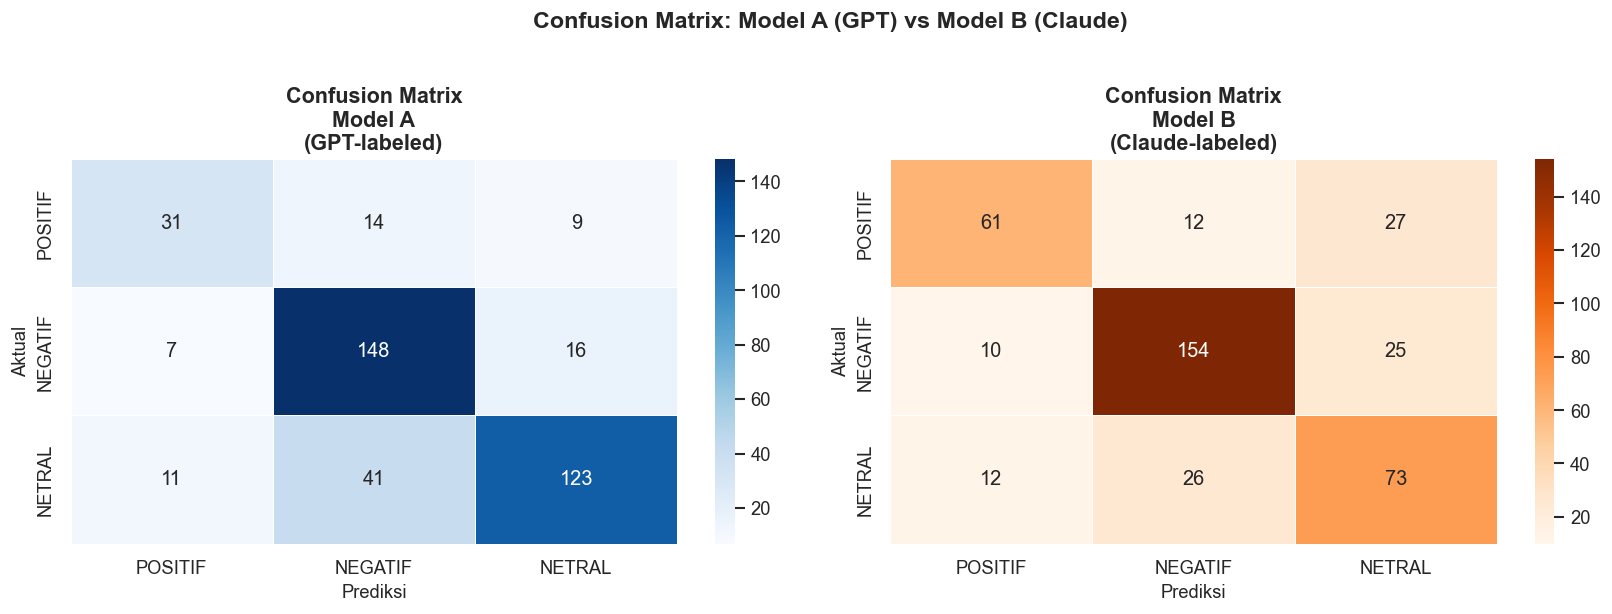

✅ Confusion matrix tersimpan


In [32]:
# ============================================================
# CELL 8B: Confusion Matrix Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title, color in zip(
    axes,
    [y_gpt_test,    y_claude_test],
    [y_pred_A,      y_pred_B],
    ["Model A\n(GPT-labeled)",  "Model B\n(Claude-labeled)"],
    ["Blues",       "Oranges"]
):
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=color,
        xticklabels=CLASSES, yticklabels=CLASSES,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f"Confusion Matrix\n{title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Prediksi", fontsize=11)
    ax.set_ylabel("Aktual", fontsize=11)

plt.suptitle("Confusion Matrix: Model A (GPT) vs Model B (Claude)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_comparison.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Confusion matrix tersimpan")

## Cell 9 — Statistical Testing
Paired T-Test + 5-Fold Stratified Cross Validation

5-FOLD STRATIFIED CROSS VALIDATION
   Model A (GPT) | Fold 1: 0.6975
   Model A (GPT) | Fold 2: 0.7025
   Model A (GPT) | Fold 3: 0.7000
   Model A (GPT) | Fold 4: 0.6875
   Model A (GPT) | Fold 5: 0.6950
   ➡️  Mean ± SD: 0.6965 ± 0.0051

   Model B (Claude) | Fold 1: 0.6800
   Model B (Claude) | Fold 2: 0.6800
   Model B (Claude) | Fold 3: 0.7125
   Model B (Claude) | Fold 4: 0.6650
   Model B (Claude) | Fold 5: 0.6525
   ➡️  Mean ± SD: 0.6780 ± 0.0201

PAIRED T-TEST (H2: ada perbedaan signifikan ≥5%)

   Mean Accuracy Model A (GPT)   : 0.6965
   Mean Accuracy Model B (Claude): 0.6780
   Selisih Mean                  : 0.0185 (1.85%)
   T-statistic                   : 2.0880
   P-value                       : 0.1051
   Confidence Interval           : 95%

   Kesimpulan (α = 0.05):
   ❌ H0 gagal ditolak: Tidak ada perbedaan signifikan (p=0.1051 ≥ 0.05)


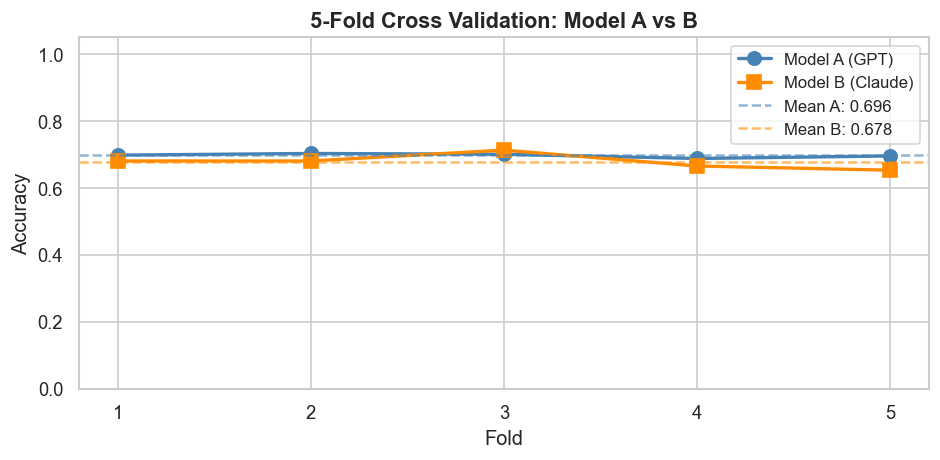


✅ Cross-validation chart tersimpan


In [33]:
# ============================================================
# CELL 9: Statistical Testing
# ============================================================

print("=" * 60)
print("5-FOLD STRATIFIED CROSS VALIDATION")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {}

for ds_name, X_all, y_all, tfidf_params in [
    ("Model A (GPT)",    X_gpt,    y_gpt,    TFIDF_PARAMS),
    ("Model B (Claude)", X_claude, y_claude, TFIDF_PARAMS),
]:
    fold_scores = []

    for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(X_all, y_all), 1):

        X_tr, X_te = X_all[train_idx], X_all[test_idx]
        y_tr, y_te = y_all[train_idx], y_all[test_idx]

        vec   = TfidfVectorizer(**tfidf_params)
        X_tr_ = vec.fit_transform(X_tr)
        X_te_ = vec.transform(X_te)

        clf   = MultinomialNB(alpha=1.0)
        clf.fit(X_tr_, y_tr)
        score = accuracy_score(y_te, clf.predict(X_te_))
        fold_scores.append(score)
        print(f"   {ds_name} | Fold {fold_idx}: {score:.4f}")

    cv_scores[ds_name] = fold_scores
    mean_cv = np.mean(fold_scores)
    std_cv  = np.std(fold_scores)
    print(f"   ➡️  Mean ± SD: {mean_cv:.4f} ± {std_cv:.4f}\n")

# --- Paired T-Test ---
print("=" * 60)
print("PAIRED T-TEST (H2: ada perbedaan signifikan ≥5%)")
print("=" * 60)

scores_A = cv_scores["Model A (GPT)"]
scores_B = cv_scores["Model B (Claude)"]

t_stat, p_value = stats.ttest_rel(scores_A, scores_B)
diff_mean = abs(np.mean(scores_A) - np.mean(scores_B))

print(f"\n   Mean Accuracy Model A (GPT)   : {np.mean(scores_A):.4f}")
print(f"   Mean Accuracy Model B (Claude): {np.mean(scores_B):.4f}")
print(f"   Selisih Mean                  : {diff_mean:.4f} ({diff_mean*100:.2f}%)")
print(f"   T-statistic                   : {t_stat:.4f}")
print(f"   P-value                       : {p_value:.4f}")
print(f"   Confidence Interval           : 95%")

alpha = 0.05
print(f"\n   Kesimpulan (α = {alpha}):")
if p_value < alpha:
    print(f"   ✅ H2 diterima: Terdapat perbedaan SIGNIFIKAN (p={p_value:.4f} < {alpha})")
    if diff_mean >= 0.05:
        print(f"      Selisih ≥5% → perbedaan praktis signifikan")
    else:
        print(f"      Selisih <5% → signifikan secara statistik, namun kecil secara praktis")
else:
    print(f"   ❌ H0 gagal ditolak: Tidak ada perbedaan signifikan (p={p_value:.4f} ≥ {alpha})")

# --- Visualisasi CV Scores ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, 6)
ax.plot(x, scores_A, "o-", color="steelblue",   label="Model A (GPT)",    linewidth=2, markersize=8)
ax.plot(x, scores_B, "s-", color="darkorange",  label="Model B (Claude)", linewidth=2, markersize=8)
ax.axhline(np.mean(scores_A), linestyle="--", color="steelblue",  alpha=0.6, label=f"Mean A: {np.mean(scores_A):.3f}")
ax.axhline(np.mean(scores_B), linestyle="--", color="darkorange", alpha=0.6, label=f"Mean B: {np.mean(scores_B):.3f}")
ax.set_xlabel("Fold", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("5-Fold Cross Validation: Model A vs B", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cv_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n✅ Cross-validation chart tersimpan")

## Cell 10 — Visualisasi
Word Cloud, Distribusi Sentimen, Top Keywords per Kelas

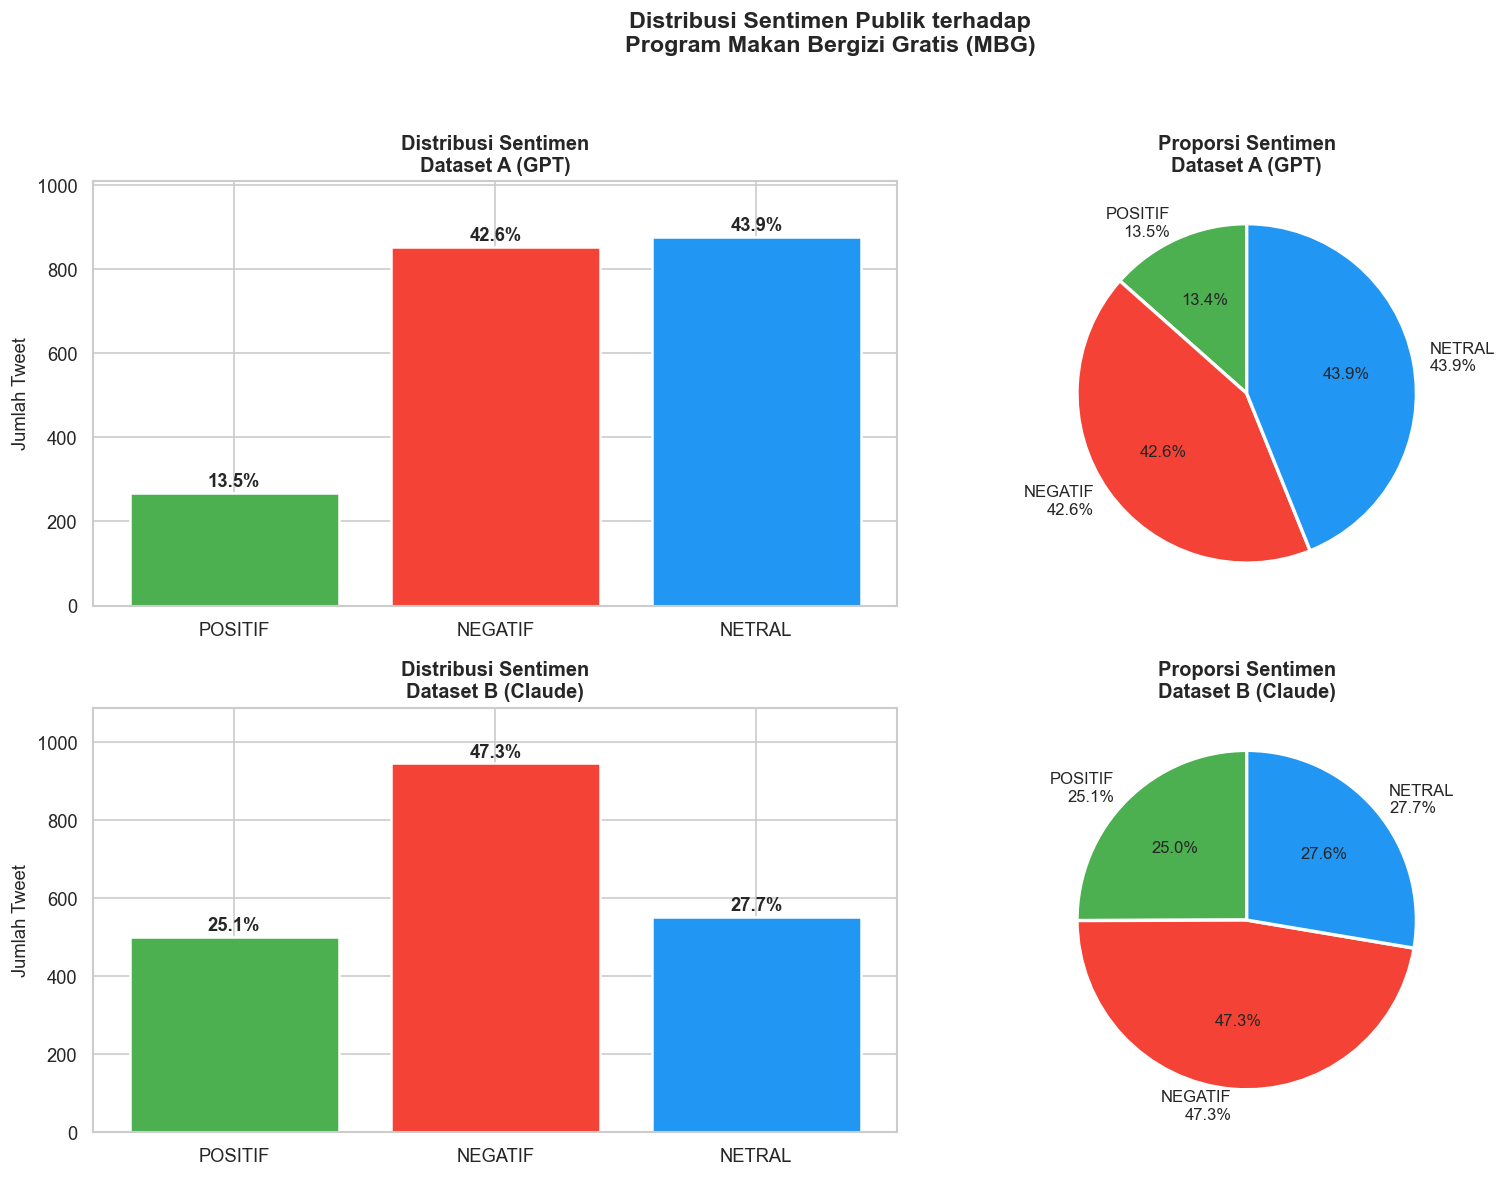

✅ Grafik distribusi sentimen tersimpan


In [34]:
# ============================================================
# CELL 10A: Distribusi Sentimen — Bar Chart & Pie Chart
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors    = {"POSITIF": "#4CAF50", "NEGATIF": "#F44336", "NETRAL": "#2196F3"}
CLASSES   = ["POSITIF", "NEGATIF", "NETRAL"]

for row_idx, (ds_name, labels_series) in enumerate([
    ("Dataset A (GPT)",    df_labeled_gpt["label_gpt"]),
    ("Dataset B (Claude)", df_labeled_claude["label_claude"])
]):
    counts  = labels_series.value_counts().reindex(CLASSES, fill_value=0)
    percents = counts / counts.sum() * 100
    bar_colors = [colors[c] for c in CLASSES]

    # Bar chart
    ax_bar = axes[row_idx][0]
    bars   = ax_bar.bar(CLASSES, counts.values, color=bar_colors, edgecolor="white", linewidth=1.5)
    for bar, pct in zip(bars, percents.values):
        ax_bar.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold"
        )
    ax_bar.set_title(f"Distribusi Sentimen\n{ds_name}", fontsize=12, fontweight="bold")
    ax_bar.set_ylabel("Jumlah Tweet", fontsize=11)
    ax_bar.set_ylim(0, counts.max() * 1.15)

    # Pie chart
    ax_pie = axes[row_idx][1]
    wedge_props = {"edgecolor": "white", "linewidth": 2}
    ax_pie.pie(
        counts.values,
        labels    = [f"{c}\n{p:.1f}%" for c, p in zip(CLASSES, percents.values)],
        colors    = bar_colors,
        autopct   = "%1.1f%%",
        startangle= 90,
        wedgeprops= wedge_props,
        textprops = {"fontsize": 10}
    )
    ax_pie.set_title(f"Proporsi Sentimen\n{ds_name}", fontsize=12, fontweight="bold")

plt.suptitle(
    "Distribusi Sentimen Publik terhadap\nProgram Makan Bergizi Gratis (MBG)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{OUTPUT_DIR}/sentiment_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Grafik distribusi sentimen tersimpan")

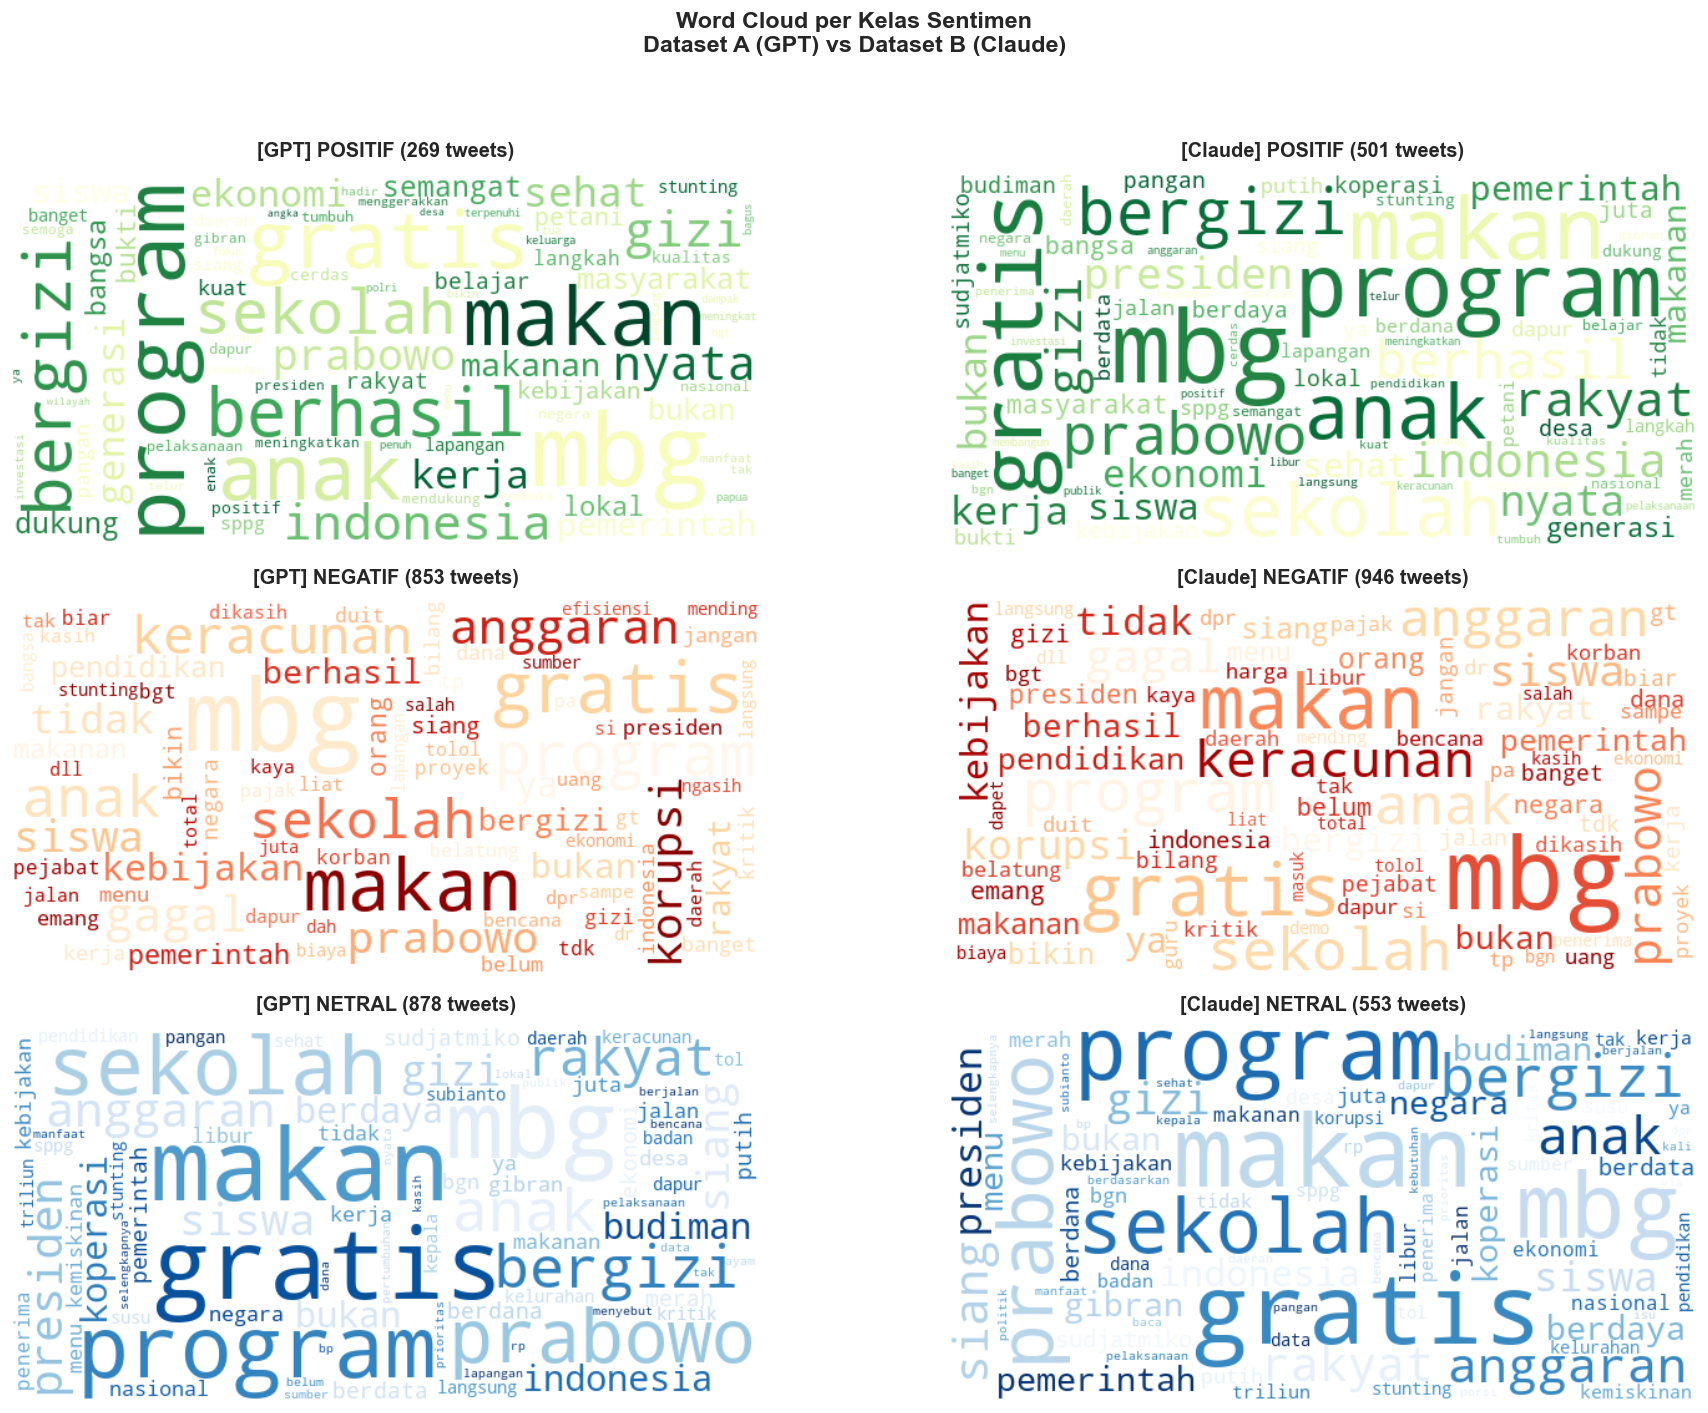

✅ Word cloud tersimpan


In [35]:
# ============================================================
# CELL 10B: Word Cloud per Kelas Sentimen
# ============================================================

def generate_wordcloud(texts: list, title: str, color: str,
                       ax: plt.Axes, background: str = "white"):
    """Generate dan tampilkan word cloud untuk kumpulan teks."""
    combined = " ".join([str(t) for t in texts if isinstance(t, str)])
    if len(combined.strip()) < 10:
        ax.text(0.5, 0.5, "Data tidak cukup",
                ha="center", va="center", transform=ax.transAxes)
        return
    wc = WordCloud(
        width            = 600,
        height           = 300,
        background_color = background,
        colormap         = color,
        max_words        = 80,
        prefer_horizontal= 0.85,
        min_font_size    = 8,
        max_font_size    = 80,
        collocations     = False
    ).generate(combined)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)


# Gunakan Dataset A (GPT) untuk word cloud utama
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for col_idx, (ds_name, df_lbl, label_col) in enumerate([
    ("GPT",    df_labeled_gpt,    "label_gpt"),
    ("Claude", df_labeled_claude, "label_claude"),
]):
    for row_idx, (sentiment, cmap) in enumerate([
        ("POSITIF", "YlGn"),
        ("NEGATIF", "OrRd"),
        ("NETRAL",  "Blues"),
    ]):
        texts = df_lbl[
            df_lbl[label_col] == sentiment
        ]["text_processed"].tolist()

        generate_wordcloud(
            texts,
            title = f"[{ds_name}] {sentiment} ({len(texts)} tweets)",
            color = cmap,
            ax    = axes[row_idx][col_idx]
        )

plt.suptitle(
    "Word Cloud per Kelas Sentimen\nDataset A (GPT) vs Dataset B (Claude)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{OUTPUT_DIR}/wordcloud_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Word cloud tersimpan")

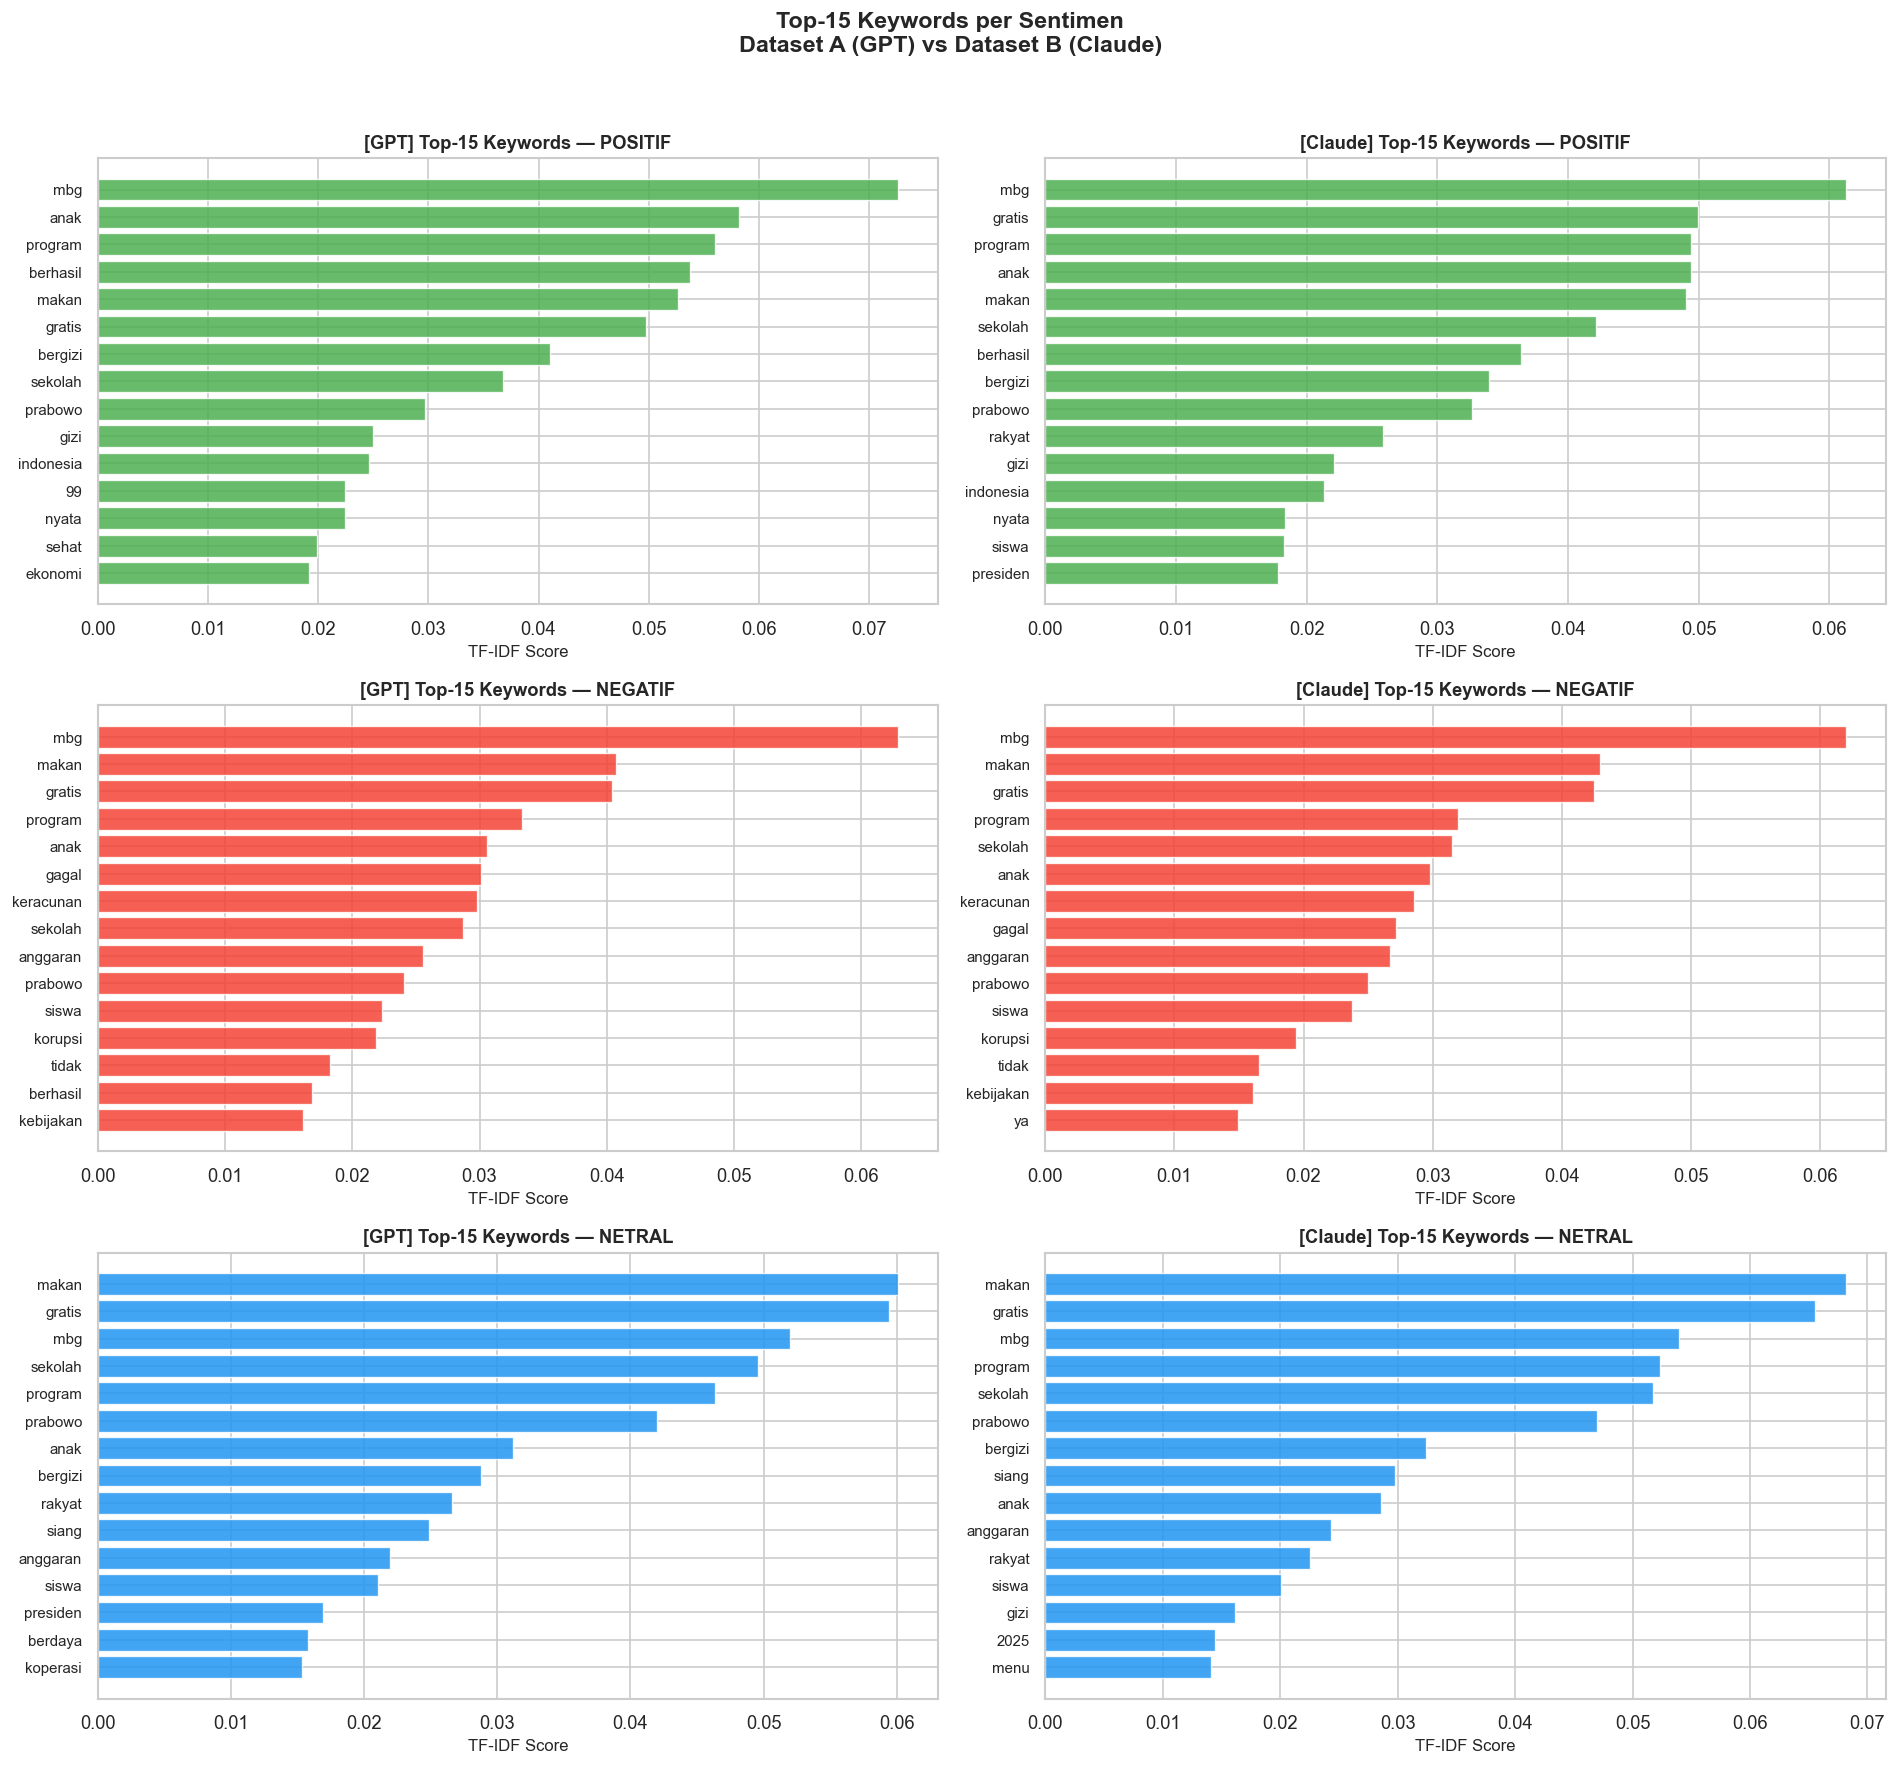

✅ Top keywords chart tersimpan


In [36]:
# ============================================================
# CELL 10C: Top Keywords per Sentimen (TF-IDF weighted)
# ============================================================

def get_top_keywords(df_lbl: pd.DataFrame, label_col: str,
                     sentiment: str, top_n: int = 20) -> pd.DataFrame:
    """Ambil top-N keywords berdasarkan TF-IDF mean score per sentimen."""
    texts = df_lbl[df_lbl[label_col] == sentiment]["text_processed"].fillna("").tolist()
    if len(texts) < 2:
        return pd.DataFrame()
    vec  = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
    tmat = vec.fit_transform(texts)
    means = np.array(tmat.mean(axis=0)).flatten()
    top_idx = means.argsort()[::-1][:top_n]
    return pd.DataFrame({
        "keyword"  : np.array(vec.get_feature_names_out())[top_idx],
        "tfidf_score": means[top_idx]
    })


fig, axes = plt.subplots(3, 2, figsize=(16, 15))
TOP_N = 15

for col_idx, (ds_name, df_lbl, label_col, palette) in enumerate([
    ("GPT",    df_labeled_gpt,    "label_gpt",    "Greens_r"),
    ("Claude", df_labeled_claude, "label_claude", "Oranges_r"),
]):
    for row_idx, (sentiment, color) in enumerate([
        ("POSITIF", "#4CAF50"),
        ("NEGATIF", "#F44336"),
        ("NETRAL",  "#2196F3"),
    ]):
        kw_df = get_top_keywords(df_lbl, label_col, sentiment, top_n=TOP_N)
        ax    = axes[row_idx][col_idx]

        if kw_df.empty:
            ax.text(0.5, 0.5, "Data tidak cukup",
                    ha="center", va="center", transform=ax.transAxes)
            continue

        bars = ax.barh(
            kw_df["keyword"][::-1],
            kw_df["tfidf_score"][::-1],
            color=color, edgecolor="white", linewidth=0.8, alpha=0.85
        )
        ax.set_title(
            f"[{ds_name}] Top-{TOP_N} Keywords — {sentiment}",
            fontsize=11, fontweight="bold"
        )
        ax.set_xlabel("TF-IDF Score", fontsize=10)
        ax.tick_params(axis="y", labelsize=9)

plt.suptitle(
    f"Top-{TOP_N} Keywords per Sentimen\nDataset A (GPT) vs Dataset B (Claude)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{OUTPUT_DIR}/top_keywords_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Top keywords chart tersimpan")

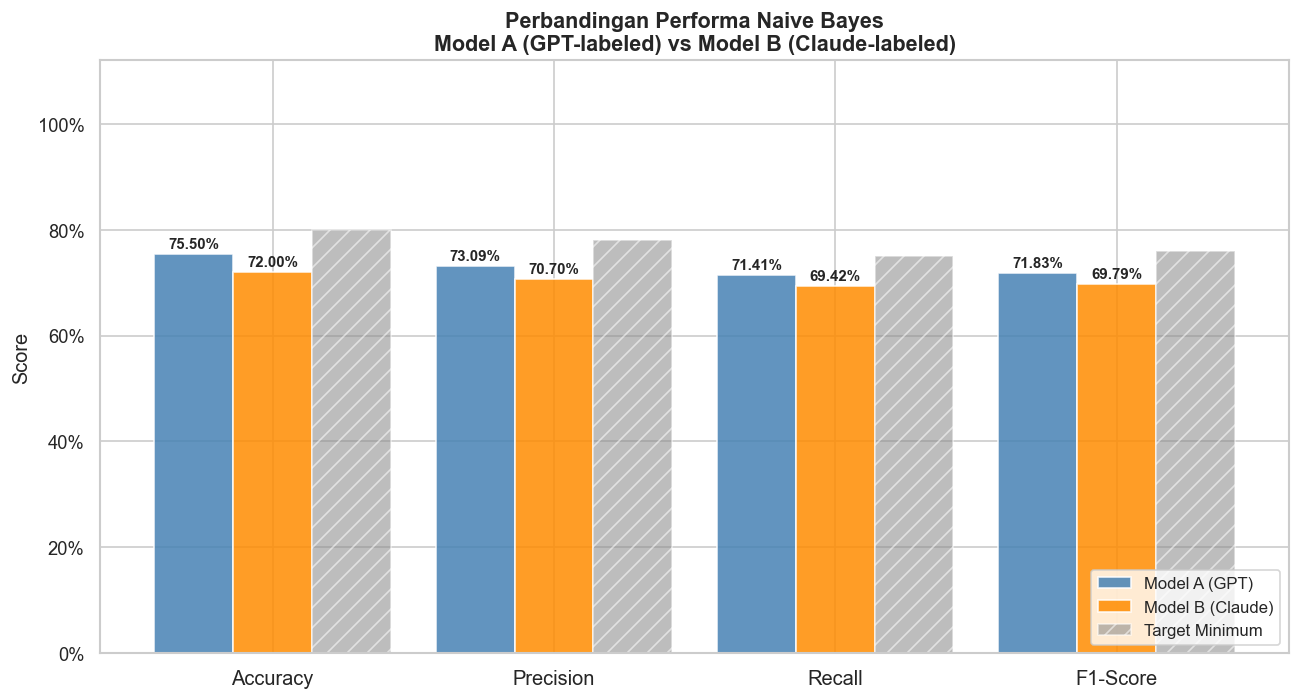

✅ Dashboard performa tersimpan


In [37]:
# ============================================================
# CELL 10D: Dashboard Ringkasan Performa Model
# ============================================================

metrics   = ["accuracy", "precision", "recall", "f1_score"]
labels_m  = ["Accuracy", "Precision", "Recall", "F1-Score"]
vals_A    = [results_A[m] for m in metrics]
vals_B    = [results_B[m] for m in metrics]
targets_v = [targets[m] for m in metrics]

x       = np.arange(len(metrics))
width   = 0.28

fig, ax = plt.subplots(figsize=(11, 6))

bars_A = ax.bar(x - width,     vals_A,    width, label="Model A (GPT)",    color="steelblue",  alpha=0.85, edgecolor="white")
bars_B = ax.bar(x,             vals_B,    width, label="Model B (Claude)", color="darkorange", alpha=0.85, edgecolor="white")
bars_T = ax.bar(x + width,     targets_v, width, label="Target Minimum",   color="#888",       alpha=0.55, edgecolor="white", hatch="//")

for bars, vals in [(bars_A, vals_A), (bars_B, vals_B)]:
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.2%}", ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(labels_m, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title(
    "Perbandingan Performa Naive Bayes\nModel A (GPT-labeled) vs Model B (Claude-labeled)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10, loc="lower right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_performance_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Dashboard performa tersimpan")

In [38]:
# ============================================================
# CELL 10E: Ringkasan Akhir & Export Laporan
# ============================================================

print("\n" + "#" * 65)
print("#  RINGKASAN AKHIR PENELITIAN")
print("#  Analisis Sentimen MBG — Naive Bayes: GPT vs Claude")
print("#" * 65)

print(f"""
📦 Dataset
   Total raw tweets    : {len(df_raw)}
   Total clean tweets  : {len(df_clean)}
   Periode             : {START_DATE} s/d {END_DATE}

🏷️  Labeling
   GPT model           : {GPT_MODEL}
   Claude model        : {CLAUDE_MODEL}
   Inter-LLM Agreement : {agreement_full:.1%}

📊 Evaluasi Model
   Model A (GPT)    — Accuracy: {results_A['accuracy']:.2%}  | F1: {results_A['f1_score']:.2%}
   Model B (Claude) — Accuracy: {results_B['accuracy']:.2%}  | F1: {results_B['f1_score']:.2%}

📐 Statistical Test
   Paired T-Test p-value : {p_value:.4f}
   Selisih Accuracy      : {diff_mean*100:.2f}%
   Kesimpulan H2         : {'Diterima ✅' if p_value < 0.05 else 'Ditolak ❌'}

💾 Output Files
   {RAW_DATA_PATH}
   {CLEAN_DATA_PATH}
   {LABELED_GPT_PATH}
   {LABELED_CLAUDE_PATH}
   {RESULTS_PATH}
   {OUTPUT_DIR}/confusion_matrix_comparison.png
   {OUTPUT_DIR}/cv_comparison.png
   {OUTPUT_DIR}/sentiment_distribution.png
   {OUTPUT_DIR}/wordcloud_comparison.png
   {OUTPUT_DIR}/top_keywords_comparison.png
   {OUTPUT_DIR}/model_performance_comparison.png
""")

print("✅ Notebook selesai dijalankan sepenuhnya!")


#################################################################
#  RINGKASAN AKHIR PENELITIAN
#  Analisis Sentimen MBG — Naive Bayes: GPT vs Claude
#################################################################

📦 Dataset
   Total raw tweets    : 2552
   Total clean tweets  : 2000
   Periode             : 2024-02-01 s/d 2025-12-31

🏷️  Labeling
   GPT model           : openai/gpt-4o-mini
   Claude model        : anthropic/claude-haiku-4-5
   Inter-LLM Agreement : 77.5%

📊 Evaluasi Model
   Model A (GPT)    — Accuracy: 75.50%  | F1: 71.83%
   Model B (Claude) — Accuracy: 72.00%  | F1: 69.79%

📐 Statistical Test
   Paired T-Test p-value : 0.1051
   Selisih Accuracy      : 1.85%
   Kesimpulan H2         : Ditolak ❌

💾 Output Files
   ./output/raw_tweets.csv
   ./output/clean_tweets.csv
   ./output/labeled_gpt.csv
   ./output/labeled_claude.csv
   ./output/evaluation_results.json
   ./output/confusion_matrix_comparison.png
   ./output/cv_comparison.png
   ./output/sentiment_distribut